# EDA del pipeline: crudo -> procesado -> map-matched -> featured

Este notebook analiza la evolucion de los datos a lo largo del pipeline:

1. Comparacion de perdida de datos antes y despues del parseo (estabilidad + GPS vs processed-data).
2. Distribuciones por variable, porcentaje de invalidos y outliers por etapa.
3. Analisis de calidad del map-matching con metricas de distancia.
4. Perdida de datos y distribuciones tras feature extraction.

Variables base analizadas: `ax`, `gx`, `gz`, `gy`, `ay`, `az`, `roll`, `pitch`, `yaw`, `si`, `accmag`, `velocidad (km/h)`.


In [1]:
from pathlib import Path
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO_ROOT = Path.cwd()
DATA_ROOT = REPO_ROOT / ".." / "Doback-Data"
GPS_DIR = DATA_ROOT / "GPS"
STABILITY_DIR = DATA_ROOT / "Stability"
PROCESSED_DIR = DATA_ROOT / "processed-data"
MAPMATCHED_DIR = DATA_ROOT / "map-matched"
FEATURED_DIR = DATA_ROOT / "featured"

MAX_PLOT_ROWS = 250000  # limita coste de render en datasets grandes
RANDOM_SEED = 42

print(f"Repo root: {REPO_ROOT}")
for p in [GPS_DIR, STABILITY_DIR, PROCESSED_DIR, MAPMATCHED_DIR, FEATURED_DIR]:
    print(f"- {p}: {'OK' if p.exists() else 'MISSING'}")


Repo root: /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/notebooks
- /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/notebooks/../Doback-Data/GPS: OK
- /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/notebooks/../Doback-Data/Stability: OK
- /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/notebooks/../Doback-Data/processed-data: OK
- /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/notebooks/../Doback-Data/map-matched: OK
- /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/notebooks/../Doback-Data/featured: OK


In [2]:
# Variables objetivo y aliases por posibles nombres en distintas etapas
BASE_VARIABLES = {
    "ax": ["ax"],
    "gx": ["gx"],
    "gz": ["gz"],
    "gy": ["gy"],
    "ay": ["ay"],
    "az": ["az"],
    "roll": ["roll"],
    "pitch": ["pitch"],
    "yaw": ["yaw"],
    "si": ["si"],
    "accmag": ["accmag"],
    "velocidad_kmh": ["speed_kmh", "velocidad_kmh", "Velocidad(km/h)", "Velocida", "velocidad"],
}

FEATURE_VARIABLES = {
    "phi_lidar": ["phi_lidar"],
    "phi_lidar_deg": ["phi_lidar_deg"],
    "tri": ["tri"],
    "ruggedness": ["ruggedness"],
    "z_min": ["z_min"],
    "z_max": ["z_max"],
    "z_mean": ["z_mean"],
    "z_std": ["z_std"],
    "z_range": ["z_range"],
    "n_points_used": ["n_points_used"],
}


def file_key_from_name(name: str) -> str | None:
    # Ejemplos esperados:
    # - GPS_DOBACK024_20251230.txt
    # - ESTABILIDAD_DOBACK024_20251230.txt
    # - DOBACK024_20251230.csv
    # - DOBACK024_20251230_seg1.csv
    m = re.search(r"(DOBACK\d+_\d{8})", name, flags=re.IGNORECASE)
    if not m:
        return None
    return m.group(1).upper()


def count_data_rows_txt(path: Path) -> int:
    # Los ficheros crudos tienen cabeceras en primeras lineas; contamos solo lineas con separadores.
    rows = 0
    with path.open("r", encoding="latin-1", errors="ignore") as f:
        for line in f:
            if ";" in line:
                rows += 1
    # Ajuste conservador para excluir lineas de cabecera tipicas
    return max(0, rows - 2)


def count_rows_csv(path: Path) -> int:
    try:
        return int(pd.read_csv(path).shape[0])
    except Exception:
        return 0


def list_csv_files(folder: Path) -> list[Path]:
    return sorted(folder.glob("*.csv")) if folder.exists() else []


def list_txt_files(folder: Path, prefix: str) -> list[Path]:
    if not folder.exists():
        return []
    return sorted(folder.glob(f"{prefix}*.txt"))


def compare_stage_counts(before_counts: dict[str, int], after_counts: dict[str, int], stage_name: str) -> pd.DataFrame:
    keys = sorted(set(before_counts) | set(after_counts))
    rows = []
    for key in keys:
        before = int(before_counts.get(key, 0))
        after = int(after_counts.get(key, 0))
        lost = max(0, before - after)
        loss_pct = (100.0 * lost / before) if before > 0 else np.nan
        rows.append({
            "stage": stage_name,
            "key": key,
            "before_rows": before,
            "after_rows": after,
            "lost_rows": lost,
            "loss_pct": loss_pct,
        })
    return pd.DataFrame(rows)


def _resolve_column(df: pd.DataFrame, aliases: list[str]) -> str | None:
    for c in aliases:
        if c in df.columns:
            return c
    lower_map = {col.lower(): col for col in df.columns}
    for c in aliases:
        match = lower_map.get(c.lower())
        if match:
            return match
    return None


def _iqr_outlier_mask(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return pd.Series(False, index=series.index)
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)


def analyze_variable(df: pd.DataFrame, var_name: str, aliases: list[str], stage_label: str) -> dict:
    col = _resolve_column(df, aliases)
    if col is None:
        return {
            "stage": stage_label,
            "variable": var_name,
            "column_used": None,
            "rows": len(df),
            "valid_rows": 0,
            "invalid_pct": 100.0 if len(df) else np.nan,
            "outlier_pct_over_valid": np.nan,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
        }

    series = pd.to_numeric(df[col], errors="coerce")
    total = len(series)
    valid_mask = series.notna() & np.isfinite(series)
    valid = series[valid_mask]

    invalid_pct = (100.0 * (total - valid_mask.sum()) / total) if total > 0 else np.nan
    if len(valid) > 0:
        out_mask = _iqr_outlier_mask(valid)
        outlier_pct = 100.0 * out_mask.mean()
    else:
        outlier_pct = np.nan

    return {
        "stage": stage_label,
        "variable": var_name,
        "column_used": col,
        "rows": total,
        "valid_rows": int(valid_mask.sum()),
        "invalid_pct": invalid_pct,
        "outlier_pct_over_valid": outlier_pct,
        "mean": float(valid.mean()) if len(valid) else np.nan,
        "std": float(valid.std()) if len(valid) else np.nan,
        "min": float(valid.min()) if len(valid) else np.nan,
        "max": float(valid.max()) if len(valid) else np.nan,
    }


def plot_variable_distribution(df: pd.DataFrame, var_name: str, aliases: list[str], stage_label: str) -> dict:
    summary = analyze_variable(df, var_name, aliases, stage_label)
    col = summary["column_used"]

    if col is None:
        print(f"[{stage_label}] {var_name}: columna no encontrada. Aliases: {aliases}")
        return summary

    series = pd.to_numeric(df[col], errors="coerce")
    valid = series[series.notna() & np.isfinite(series)]

    if len(valid) == 0:
        print(f"[{stage_label}] {var_name}: sin valores numericos validos")
        return summary

    if len(valid) > MAX_PLOT_ROWS:
        plot_vals = valid.sample(MAX_PLOT_ROWS, random_state=RANDOM_SEED)
    else:
        plot_vals = valid

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(plot_vals, bins=60, kde=True, ax=axes[0], color="#1f77b4")
    axes[0].set_title(f"{stage_label} - {var_name} (histograma)")
    axes[0].set_xlabel(col)

    sns.boxplot(x=plot_vals, ax=axes[1], color="#ff7f0e")
    axes[1].set_title(f"{stage_label} - {var_name} (boxplot)")
    axes[1].set_xlabel(col)

    fig.tight_layout()
    plt.show()

    print(
        f"[{stage_label}] {var_name} | col={col} | "
        f"invalid_pct={summary['invalid_pct']:.2f}% | "
        f"outlier_pct={summary['outlier_pct_over_valid']:.2f}% | "
        f"valid_rows={summary['valid_rows']}"
    )
    return summary


def plot_variable_comparison_same_scale(
    df_left: pd.DataFrame,
    df_right: pd.DataFrame,
    var_name: str,
    aliases: list[str],
    left_label: str,
    right_label: str,
) -> tuple[dict, dict]:
    left_summary = analyze_variable(df_left, var_name, aliases, left_label)
    right_summary = analyze_variable(df_right, var_name, aliases, right_label)

    left_col = left_summary["column_used"]
    right_col = right_summary["column_used"]

    if left_col is None or right_col is None:
        print(
            f"[{var_name}] comparacion omitida: columna no encontrada en uno de los datasets "
            f"({left_label}={left_col}, {right_label}={right_col})"
        )
        return left_summary, right_summary

    left_series = pd.to_numeric(df_left[left_col], errors="coerce")
    right_series = pd.to_numeric(df_right[right_col], errors="coerce")
    left_valid = left_series[left_series.notna() & np.isfinite(left_series)]
    right_valid = right_series[right_series.notna() & np.isfinite(right_series)]

    if len(left_valid) == 0 or len(right_valid) == 0:
        print(
            f"[{var_name}] comparacion omitida: faltan valores validos "
            f"({left_label}={len(left_valid)}, {right_label}={len(right_valid)})"
        )
        return left_summary, right_summary

    left_plot = (
        left_valid.sample(MAX_PLOT_ROWS, random_state=RANDOM_SEED)
        if len(left_valid) > MAX_PLOT_ROWS
        else left_valid
    )
    right_plot = (
        right_valid.sample(MAX_PLOT_ROWS, random_state=RANDOM_SEED)
        if len(right_valid) > MAX_PLOT_ROWS
        else right_valid
    )

    combined = pd.concat([left_plot, right_plot], ignore_index=True)
    x_min = float(combined.min())
    x_max = float(combined.max())
    if x_min == x_max:
        delta = 1.0 if x_min == 0 else abs(x_min) * 0.01
        x_min -= delta
        x_max += delta
    bins = np.linspace(x_min, x_max, 61)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    sns.histplot(left_plot, bins=bins, kde=True, ax=axes[0, 0], color="#1f77b4")
    axes[0, 0].set_title(f"{left_label} - {var_name} (histograma)")
    axes[0, 0].set_xlim(x_min, x_max)

    sns.histplot(right_plot, bins=bins, kde=True, ax=axes[0, 1], color="#2ca02c")
    axes[0, 1].set_title(f"{right_label} - {var_name} (histograma)")
    axes[0, 1].set_xlim(x_min, x_max)

    sns.boxplot(x=left_plot, ax=axes[1, 0], color="#ff7f0e")
    axes[1, 0].set_title(f"{left_label} - {var_name} (boxplot)")
    axes[1, 0].set_xlim(x_min, x_max)

    sns.boxplot(x=right_plot, ax=axes[1, 1], color="#d62728")
    axes[1, 1].set_title(f"{right_label} - {var_name} (boxplot)")
    axes[1, 1].set_xlim(x_min, x_max)

    # Igualamos escala Y de histogramas para comparacion visual justa.
    y_max = max(axes[0, 0].get_ylim()[1], axes[0, 1].get_ylim()[1])
    axes[0, 0].set_ylim(0, y_max)
    axes[0, 1].set_ylim(0, y_max)

    for ax in axes.flat:
        ax.tick_params(axis="x", labelbottom=True)
        ax.grid(True, alpha=0.25)

    fig.suptitle(f"Comparacion con misma escala: {var_name}", y=1.02)
    fig.tight_layout()
    plt.show()

    print(
        f"[{var_name}] escalas igualadas | x_range=({x_min:.4f}, {x_max:.4f}) | "
        f"y_hist_max={y_max:.2f}"
    )
    print(
        f"[{left_label}] invalid_pct={left_summary['invalid_pct']:.2f}% "
        f"outlier_pct={left_summary['outlier_pct_over_valid']:.2f}%"
    )
    print(
        f"[{right_label}] invalid_pct={right_summary['invalid_pct']:.2f}% "
        f"outlier_pct={right_summary['outlier_pct_over_valid']:.2f}%"
    )

    return left_summary, right_summary


def load_stability_raw_dataframe(stability_files: list[Path]) -> pd.DataFrame:
    rows = []
    expected_cols = [
        "ax", "ay", "az", "gx", "gy", "gz", "roll", "pitch", "yaw",
        "timeantwifi", "usciclo1", "usciclo2", "usciclo3", "usciclo4", "usciclo5",
        "si", "accmag", "microsds", "k3"
    ]
    for fp in stability_files:
        key = file_key_from_name(fp.name)
        with fp.open("r", encoding="latin-1", errors="ignore") as f:
            lines = [ln.strip() for ln in f if ln.strip()]
        data_lines = []
        for ln in lines:
            # En bruto las filas de datos suelen ser valores separados por ';'.
            if ln.count(";") >= 10 and not ln.upper().startswith("ESTABILIDAD") and not ln.lower().startswith("ax;"):
                data_lines.append(ln)
        for ln in data_lines:
            parts = [p.strip() for p in ln.split(";")]
            if len(parts) < len(expected_cols):
                continue
            row = {col: parts[i] for i, col in enumerate(expected_cols)}
            row["source_key"] = key
            rows.append(row)

    if not rows:
        return pd.DataFrame(columns=expected_cols + ["source_key"])

    df = pd.DataFrame(rows)
    for col in expected_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def load_stage_dataframe(csv_files: list[Path]) -> pd.DataFrame:
    frames = []
    for fp in csv_files:
        try:
            dfi = pd.read_csv(fp)
        except Exception:
            continue
        dfi["source_file"] = fp.name
        dfi["source_key"] = file_key_from_name(fp.name)
        frames.append(dfi)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def print_global_loss(df_cmp: pd.DataFrame, label: str) -> None:
    before_total = int(df_cmp["before_rows"].sum())
    after_total = int(df_cmp["after_rows"].sum())
    lost_total = max(0, before_total - after_total)
    loss_pct = (100.0 * lost_total / before_total) if before_total > 0 else np.nan
    print(f"{label}: before={before_total:,} after={after_total:,} lost={lost_total:,} loss_pct={loss_pct:.2f}%")


def haversine_m(lat1, lon1, lat2, lon2):
    r = 6371000.0
    p = math.pi / 180.0
    dlat = (lat2 - lat1) * p
    dlon = (lon2 - lon1) * p
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin(dlon / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(a))


## Fase 2 - Crudo vs procesado (comparacion antes/despues del parse)

En esta fase no se implementa parseo nuevo: se comparan directamente los archivos crudos y los procesados para medir la perdida de filas.
Tambien se generan graficas de distribucion por variable con porcentaje de invalidos y outliers.


In [3]:
# 1) Conteos por etapa cruda y procesada

gps_files = list_txt_files(GPS_DIR, "GPS_")
stability_files = list_txt_files(STABILITY_DIR, "ESTABILIDAD_")
processed_csv = list_csv_files(PROCESSED_DIR)

print(f"GPS files: {len(gps_files)}")
print(f"Stability files: {len(stability_files)}")
print(f"Processed csv files: {len(processed_csv)}")

raw_stability_counts = {}
for fp in stability_files:
    key = file_key_from_name(fp.name)
    if key is None:
        continue
    raw_stability_counts[key] = raw_stability_counts.get(key, 0) + count_data_rows_txt(fp)

processed_counts = {}
for fp in processed_csv:
    key = file_key_from_name(fp.name)
    if key is None:
        continue
    processed_counts[key] = processed_counts.get(key, 0) + count_rows_csv(fp)

df_parse_cmp = compare_stage_counts(raw_stability_counts, processed_counts, "raw_stability_vs_processed")
print_global_loss(df_parse_cmp, "Perdida parse (stability -> processed)")

display(df_parse_cmp.sort_values("loss_pct", ascending=False).head(20))

# 2) Dataframes para distribuciones
raw_stability_df = load_stability_raw_dataframe(stability_files)
processed_df = load_stage_dataframe(processed_csv)

print(f"raw_stability_df shape: {raw_stability_df.shape}")
print(f"processed_df shape: {processed_df.shape}")


GPS files: 471
Stability files: 472
Processed csv files: 1216
Perdida parse (stability -> processed): before=37,951,785 after=2,022,176 lost=35,929,609 loss_pct=94.67%


,stage,key,before_rows,after_rows,lost_rows,loss_pct
466,raw_stability_vs_processed,DOBACK028_20260220,3030,0,3030,100.0
0,raw_stability_vs_processed,DOBACK023_20250930,8596,0,8596,100.0
1,raw_stability_vs_processed,DOBACK023_20251004,12497,0,12497,100.0
2,raw_stability_vs_processed,DOBACK023_20251008,25844,0,25844,100.0
3,raw_stability_vs_processed,DOBACK023_20251010,5857,0,5857,100.0
4,raw_stability_vs_processed,DOBACK023_20251011,2938,0,2938,100.0
464,raw_stability_vs_processed,DOBACK028_20260218,108642,0,108642,100.0
6,raw_stability_vs_processed,DOBACK023_20251013,2931,0,2931,100.0
7,raw_stability_vs_processed,DOBACK023_20251016,32280,0,32280,100.0
8,raw_stability_vs_processed,DOBACK023_20251017,5747,0,5747,100.0


raw_stability_df shape: (37947071, 20)
processed_df shape: (2022176, 63)


Resumen global de atribucion
- Keys analizadas: 468
- Keys con cuello en GPS: 466
- Keys con cuello en ESTABILIDAD: 1
- Keys balanceadas: 1

Top 20 por perdida despues del solape (posible problema de parse/merge):


,key,processed_rows,gps_raw_rows,gps_valid_rows,gps_no_fix_rows,gps_malformed_rows,stability_raw_rows,stability_valid_rows,stability_malformed_rows,common_theoretical_rows,loss_after_overlap_rows,potential_cut_by_gps,potential_cut_by_stability,dominant_source,proc_over_gps_valid_pct,proc_over_stability_valid_pct,proc_over_common_theoretical_pct
339,DOBACK028_20251015,0,10573,9779,778,16,82130,82130,0,9779,9779,72351,0,GPS,0.000000,0.000000,0.000000
325,DOBACK028_20251001,593,8469,8162,294,13,98196,98196,0,8162,7569,90034,0,GPS,7.265376,0.603894,7.265376
74,DOBACK024_20251024,0,7860,7248,609,3,98823,98823,0,7248,7248,91575,0,GPS,0.000000,0.000000,0.000000
68,DOBACK024_20251018,37,8238,7270,960,8,145022,145022,0,7270,7233,137752,0,GPS,0.508941,0.025513,0.508941
330,DOBACK028_20251006,88,7553,7267,225,61,78009,78009,0,7267,7179,70742,0,GPS,1.210954,0.112807,1.210954
334,DOBACK028_20251010,44,7536,6856,669,11,86032,86032,0,6856,6812,79176,0,GPS,0.641774,0.051144,0.641774
368,DOBACK028_20251113,139,7297,6431,849,17,100345,100345,0,6431,6292,93914,0,GPS,2.161406,0.138522,2.161406
96,DOBACK024_20251115,0,10976,6074,2510,2392,193946,193936,10,6074,6074,187862,0,GPS,0.000000,0.000000,0.000000
71,DOBACK024_20251021,93,6833,6077,751,5,154413,154413,0,6077,5984,148336,0,GPS,1.530360,0.060228,1.530360
348,DOBACK028_20251024,1570,8328,7468,829,31,65461,65461,0,7468,5898,57993,0,GPS,21.023032,2.398375,21.023032



Top 20 donde GPS limita mas:


,key,processed_rows,gps_raw_rows,gps_valid_rows,gps_no_fix_rows,gps_malformed_rows,stability_raw_rows,stability_valid_rows,stability_malformed_rows,common_theoretical_rows,loss_after_overlap_rows,potential_cut_by_gps,potential_cut_by_stability,dominant_source,proc_over_gps_valid_pct,proc_over_stability_valid_pct,proc_over_common_theoretical_pct
175,DOBACK024_20260214,0,37954,0,0,37954,399840,399840,0,0,0,399840,0,GPS,NaN,0.000000,NaN
444,DOBACK028_20260128,0,29590,0,0,29590,354682,354682,0,0,0,354682,0,GPS,NaN,0.000000,NaN
346,DOBACK028_20251022,0,1607,1327,272,8,337513,337513,0,1327,1327,336186,0,GPS,0.000000,0.000000,0.000000
463,DOBACK028_20260216,0,25953,0,0,25953,333054,333054,0,0,0,333054,0,GPS,NaN,0.000000,NaN
313,DOBACK027_20260214,0,11596,0,0,11596,314595,314595,0,0,0,314595,0,GPS,NaN,0.000000,NaN
5,DOBACK023_20251012,381545,25811,25714,96,1,339364,339364,0,25714,0,313650,0,GPS,1483.802598,112.429427,1483.802598
73,DOBACK024_20251023,65630,18283,17212,1064,7,317461,317461,0,17212,0,300249,0,GPS,381.303742,20.673406,381.303742
304,DOBACK027_20260205,0,19343,0,0,19343,298303,298303,0,0,0,298303,0,GPS,NaN,0.000000,NaN
441,DOBACK028_20260125,0,25191,0,0,25191,292547,292545,2,0,0,292545,0,GPS,NaN,0.000000,NaN
315,DOBACK027_20260216,0,23900,0,0,23900,287156,287156,0,0,0,287156,0,GPS,NaN,0.000000,NaN



Top 20 donde Estabilidad limita mas:


,key,processed_rows,gps_raw_rows,gps_valid_rows,gps_no_fix_rows,gps_malformed_rows,stability_raw_rows,stability_valid_rows,stability_malformed_rows,common_theoretical_rows,loss_after_overlap_rows,potential_cut_by_gps,potential_cut_by_stability,dominant_source,proc_over_gps_valid_pct,proc_over_stability_valid_pct,proc_over_common_theoretical_pct
186,DOBACK027_20250814,0,1787,1481,306,0,0,0,0,0,0,0,1481,ESTABILIDAD,0.0,NaN,NaN
319,DOBACK027_20260220,0,4995,0,0,4995,67626,67626,0,0,0,67626,0,GPS,NaN,0.0,NaN
318,DOBACK027_20260219,0,5681,0,0,5681,67939,67939,0,0,0,67939,0,GPS,NaN,0.0,NaN
317,DOBACK027_20260218,0,4706,0,0,4706,55377,55377,0,0,0,55377,0,GPS,NaN,0.0,NaN
316,DOBACK027_20260217,0,5588,0,0,5588,67697,67697,0,0,0,67697,0,GPS,NaN,0.0,NaN
315,DOBACK027_20260216,0,23900,0,0,23900,287156,287156,0,0,0,287156,0,GPS,NaN,0.0,NaN
314,DOBACK027_20260215,0,16580,0,0,16580,200566,200566,0,0,0,200566,0,GPS,NaN,0.0,NaN
313,DOBACK027_20260214,0,11596,0,0,11596,314595,314595,0,0,0,314595,0,GPS,NaN,0.0,NaN
312,DOBACK027_20260213,0,24286,0,0,24286,247098,247098,0,0,0,247098,0,GPS,NaN,0.0,NaN
311,DOBACK027_20260212,0,2533,0,0,2533,29958,29958,0,0,0,29958,0,GPS,NaN,0.0,NaN


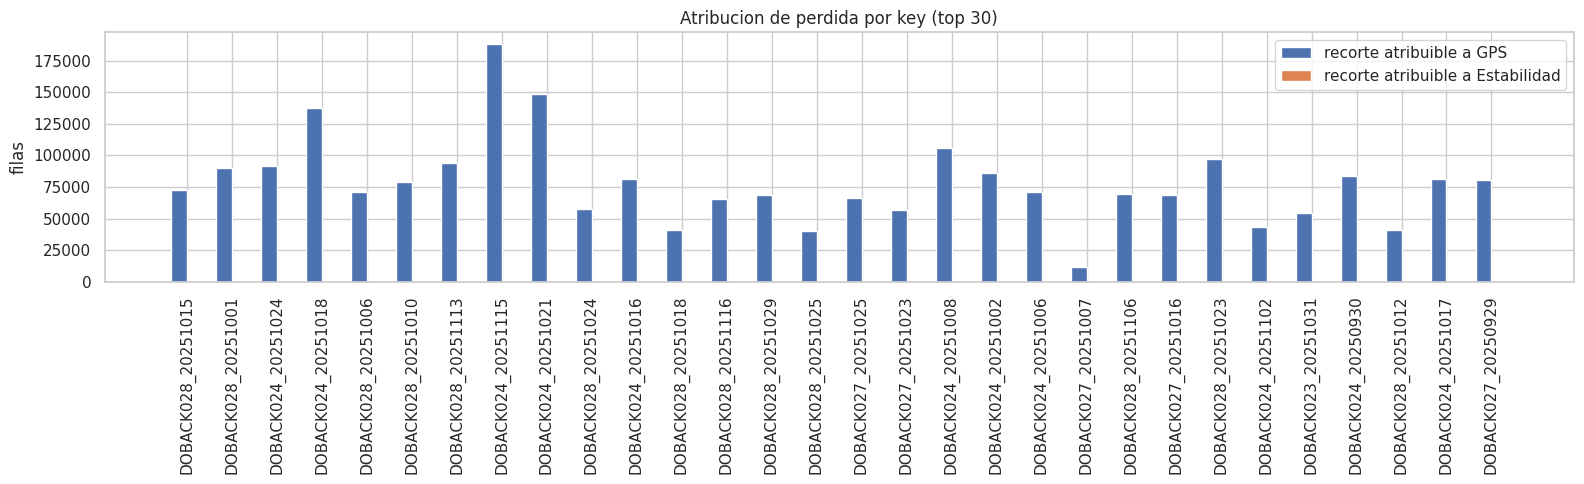

In [4]:
# 1.1) Atribucion de perdida de parse: GPS vs Estabilidad
# Determina para cada key si el cuello de botella para llegar a processed viene mas por GPS o por Estabilidad.

def _to_float_or_nan(x):
    try:
        return float(str(x).strip().replace(",", "."))
    except Exception:
        return np.nan


def count_gps_rows_detail(path: Path) -> dict:
    raw_rows = 0
    valid_rows = 0
    no_fix_rows = 0
    malformed_rows = 0

    with path.open("r", encoding="latin-1", errors="ignore") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    # Estructura esperada: metadata, cabecera, datos
    for ln in lines[2:]:
        raw_rows += 1

        if "sin datos gps" in ln.lower():
            no_fix_rows += 1
            continue

        parts = [p.strip() for p in ln.split(",")]
        if len(parts) < 10:
            malformed_rows += 1
            continue

        lat = _to_float_or_nan(parts[3])
        lon = _to_float_or_nan(parts[4])
        if np.isnan(lat) or np.isnan(lon):
            no_fix_rows += 1
            continue

        valid_rows += 1

    return {
        "raw_rows": raw_rows,
        "valid_rows": valid_rows,
        "no_fix_rows": no_fix_rows,
        "malformed_rows": malformed_rows,
    }


def count_stability_rows_detail(path: Path) -> dict:
    raw_rows = 0
    valid_rows = 0
    malformed_rows = 0

    with path.open("r", encoding="latin-1", errors="ignore") as f:
        for ln in f:
            s = ln.strip()
            if not s:
                continue
            if s.upper().startswith("ESTABILIDAD") or s.lower().startswith("ax;"):
                continue
            if s.count(";") < 10:
                continue

            raw_rows += 1
            parts = [p.strip() for p in s.split(";")]
            while parts and parts[-1] == "":
                parts.pop()

            if len(parts) < 19:
                malformed_rows += 1
                continue

            ax = _to_float_or_nan(parts[0])
            az = _to_float_or_nan(parts[2])
            gy = _to_float_or_nan(parts[4])
            si = _to_float_or_nan(parts[15])

            if np.isnan(ax) or np.isnan(az) or np.isnan(gy) or np.isnan(si):
                malformed_rows += 1
                continue

            valid_rows += 1

    return {
        "raw_rows": raw_rows,
        "valid_rows": valid_rows,
        "malformed_rows": malformed_rows,
    }


gps_detail = {}
for fp in gps_files:
    key = file_key_from_name(fp.name)
    if key is None:
        continue
    d = count_gps_rows_detail(fp)
    acc = gps_detail.get(key, {"raw_rows": 0, "valid_rows": 0, "no_fix_rows": 0, "malformed_rows": 0})
    for k in d:
        acc[k] += int(d[k])
    gps_detail[key] = acc

stability_detail = {}
for fp in stability_files:
    key = file_key_from_name(fp.name)
    if key is None:
        continue
    d = count_stability_rows_detail(fp)
    acc = stability_detail.get(key, {"raw_rows": 0, "valid_rows": 0, "malformed_rows": 0})
    for k in d:
        acc[k] += int(d[k])
    stability_detail[key] = acc

keys = sorted(set(processed_counts) | set(gps_detail) | set(stability_detail))
rows = []

for key in keys:
    gps_raw = int(gps_detail.get(key, {}).get("raw_rows", 0))
    gps_valid = int(gps_detail.get(key, {}).get("valid_rows", 0))
    gps_no_fix = int(gps_detail.get(key, {}).get("no_fix_rows", 0))
    gps_bad = int(gps_detail.get(key, {}).get("malformed_rows", 0))

    stab_raw = int(stability_detail.get(key, {}).get("raw_rows", 0))
    stab_valid = int(stability_detail.get(key, {}).get("valid_rows", 0))
    stab_bad = int(stability_detail.get(key, {}).get("malformed_rows", 0))

    proc = int(processed_counts.get(key, 0))

    common_theoretical = min(gps_valid, stab_valid)
    loss_after_overlap = max(0, common_theoretical - proc)

    potential_cut_by_gps = max(0, stab_valid - gps_valid)
    potential_cut_by_stability = max(0, gps_valid - stab_valid)

    if gps_valid < stab_valid:
        dominant_source = "GPS"
    elif stab_valid < gps_valid:
        dominant_source = "ESTABILIDAD"
    else:
        dominant_source = "BALANCEADO"

    rows.append(
        {
            "key": key,
            "processed_rows": proc,
            "gps_raw_rows": gps_raw,
            "gps_valid_rows": gps_valid,
            "gps_no_fix_rows": gps_no_fix,
            "gps_malformed_rows": gps_bad,
            "stability_raw_rows": stab_raw,
            "stability_valid_rows": stab_valid,
            "stability_malformed_rows": stab_bad,
            "common_theoretical_rows": common_theoretical,
            "loss_after_overlap_rows": loss_after_overlap,
            "potential_cut_by_gps": potential_cut_by_gps,
            "potential_cut_by_stability": potential_cut_by_stability,
            "dominant_source": dominant_source,
            "proc_over_gps_valid_pct": (100.0 * proc / gps_valid) if gps_valid > 0 else np.nan,
            "proc_over_stability_valid_pct": (100.0 * proc / stab_valid) if stab_valid > 0 else np.nan,
            "proc_over_common_theoretical_pct": (100.0 * proc / common_theoretical) if common_theoretical > 0 else np.nan,
        }
    )

df_attr = pd.DataFrame(rows)

print("Resumen global de atribucion")
print(f"- Keys analizadas: {len(df_attr)}")
print(f"- Keys con cuello en GPS: {(df_attr['dominant_source'] == 'GPS').sum()}")
print(f"- Keys con cuello en ESTABILIDAD: {(df_attr['dominant_source'] == 'ESTABILIDAD').sum()}")
print(f"- Keys balanceadas: {(df_attr['dominant_source'] == 'BALANCEADO').sum()}")

print("\nTop 20 por perdida despues del solape (posible problema de parse/merge):")
display(df_attr.sort_values("loss_after_overlap_rows", ascending=False).head(20))

print("\nTop 20 donde GPS limita mas:")
display(df_attr.sort_values("potential_cut_by_gps", ascending=False).head(20))

print("\nTop 20 donde Estabilidad limita mas:")
display(df_attr.sort_values("potential_cut_by_stability", ascending=False).head(20))

plot_df = df_attr.sort_values("loss_after_overlap_rows", ascending=False).head(30).copy()

x = np.arange(len(plot_df))
w = 0.35
plt.figure(figsize=(16, 5))
plt.bar(x - w / 2, plot_df["potential_cut_by_gps"], width=w, label="recorte atribuible a GPS")
plt.bar(x + w / 2, plot_df["potential_cut_by_stability"], width=w, label="recorte atribuible a Estabilidad")
plt.xticks(x, plot_df["key"], rotation=90)
plt.ylabel("filas")
plt.title("Atribucion de perdida por key (top 30)")
plt.legend()
plt.tight_layout()
plt.show()

Variable: ax (RAW STABILITY vs PROCESSED, misma escala)


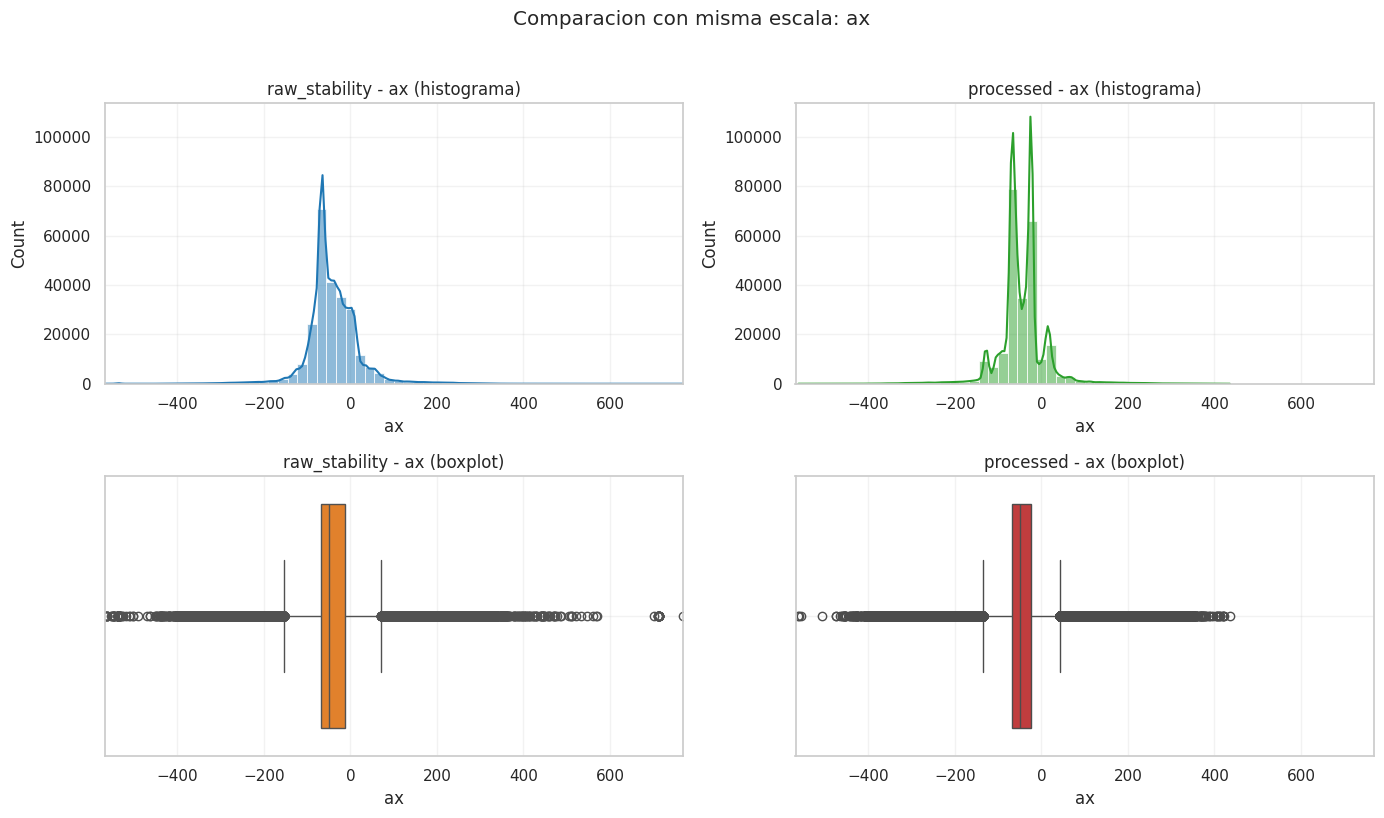

[ax] escalas igualadas | x_range=(-568.2800, 768.8400) | y_hist_max=113594.34
[raw_stability] invalid_pct=0.00% outlier_pct=5.53%
[processed] invalid_pct=0.00% outlier_pct=6.21%
Variable: gx (RAW STABILITY vs PROCESSED, misma escala)


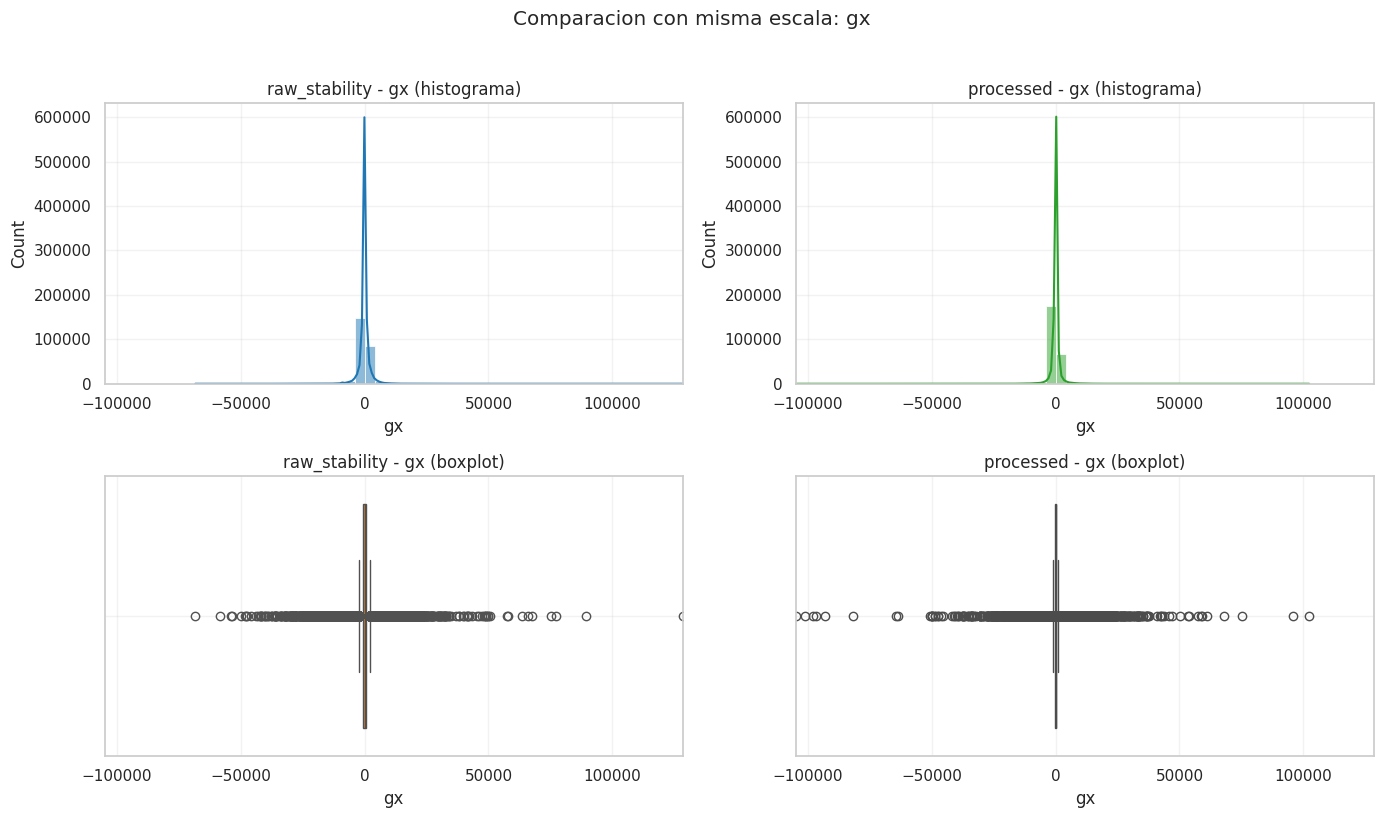

[gx] escalas igualadas | x_range=(-105038.0600, 128567.6900) | y_hist_max=631149.90
[raw_stability] invalid_pct=0.00% outlier_pct=15.24%
[processed] invalid_pct=0.00% outlier_pct=20.73%
Variable: gz (RAW STABILITY vs PROCESSED, misma escala)


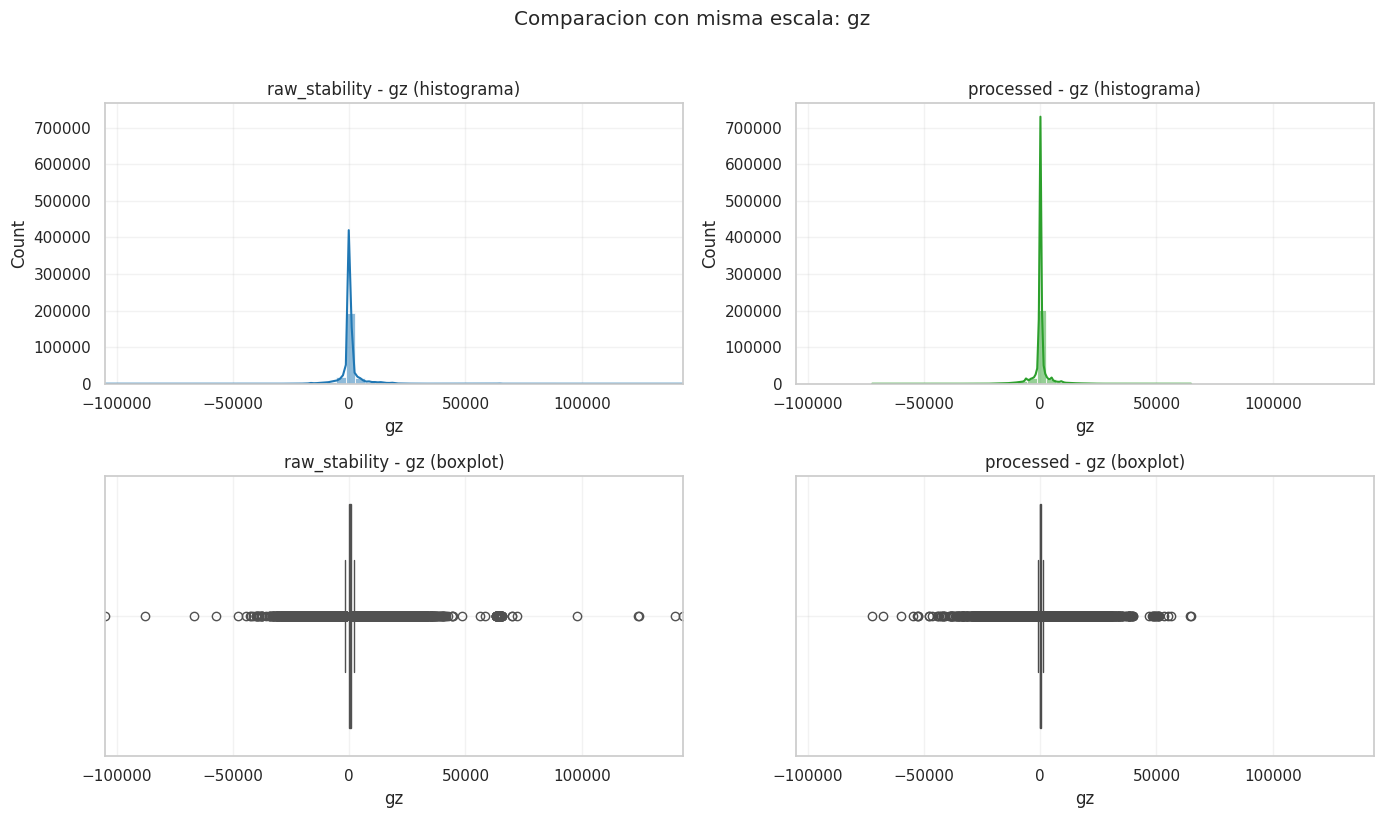

[gz] escalas igualadas | x_range=(-105207.3800, 143570.7000) | y_hist_max=766343.37
[raw_stability] invalid_pct=0.00% outlier_pct=24.34%
[processed] invalid_pct=0.00% outlier_pct=27.89%
Variable: gy (RAW STABILITY vs PROCESSED, misma escala)


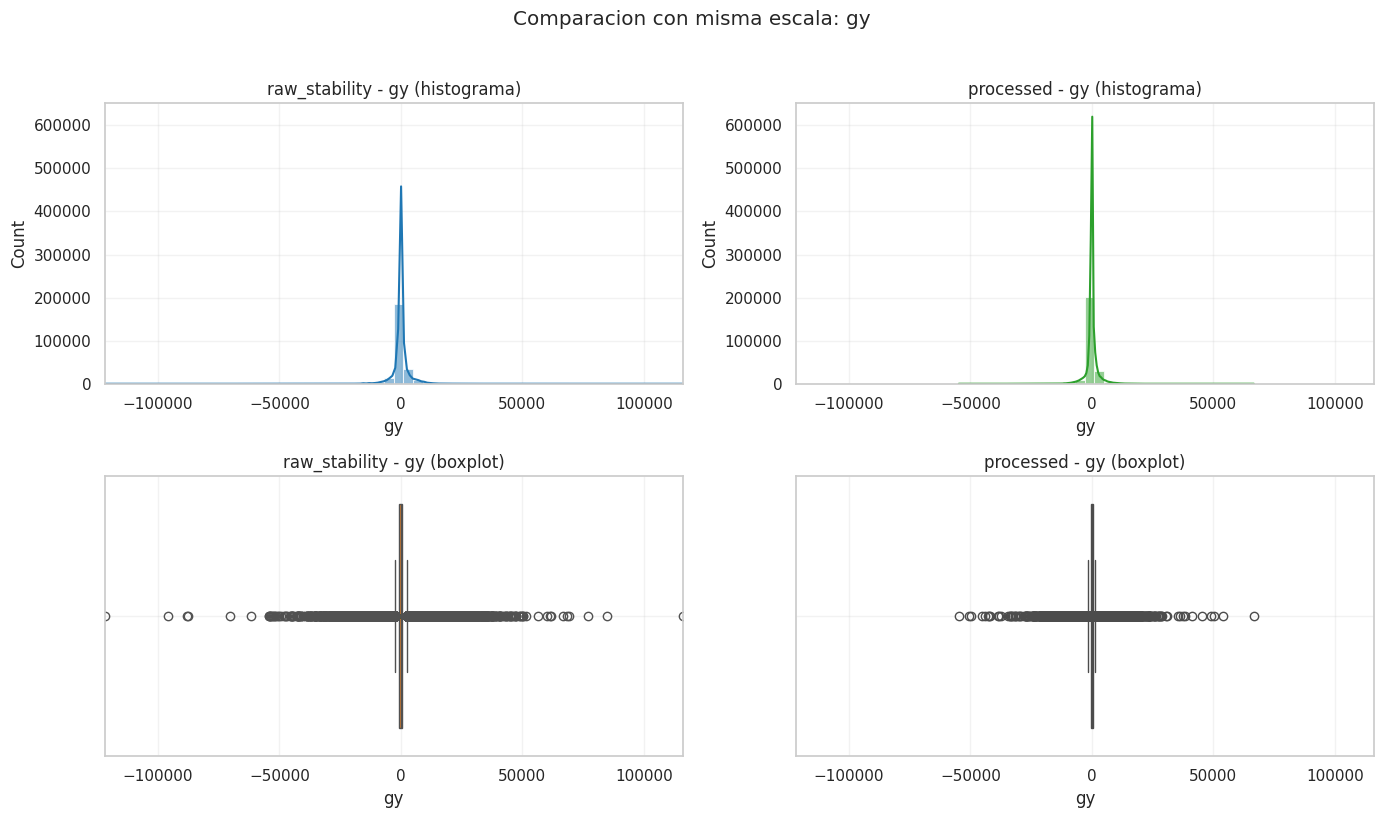

[gy] escalas igualadas | x_range=(-121956.0200, 116111.1000) | y_hist_max=650898.71
[raw_stability] invalid_pct=0.00% outlier_pct=18.15%
[processed] invalid_pct=0.00% outlier_pct=20.13%
Variable: ay (RAW STABILITY vs PROCESSED, misma escala)


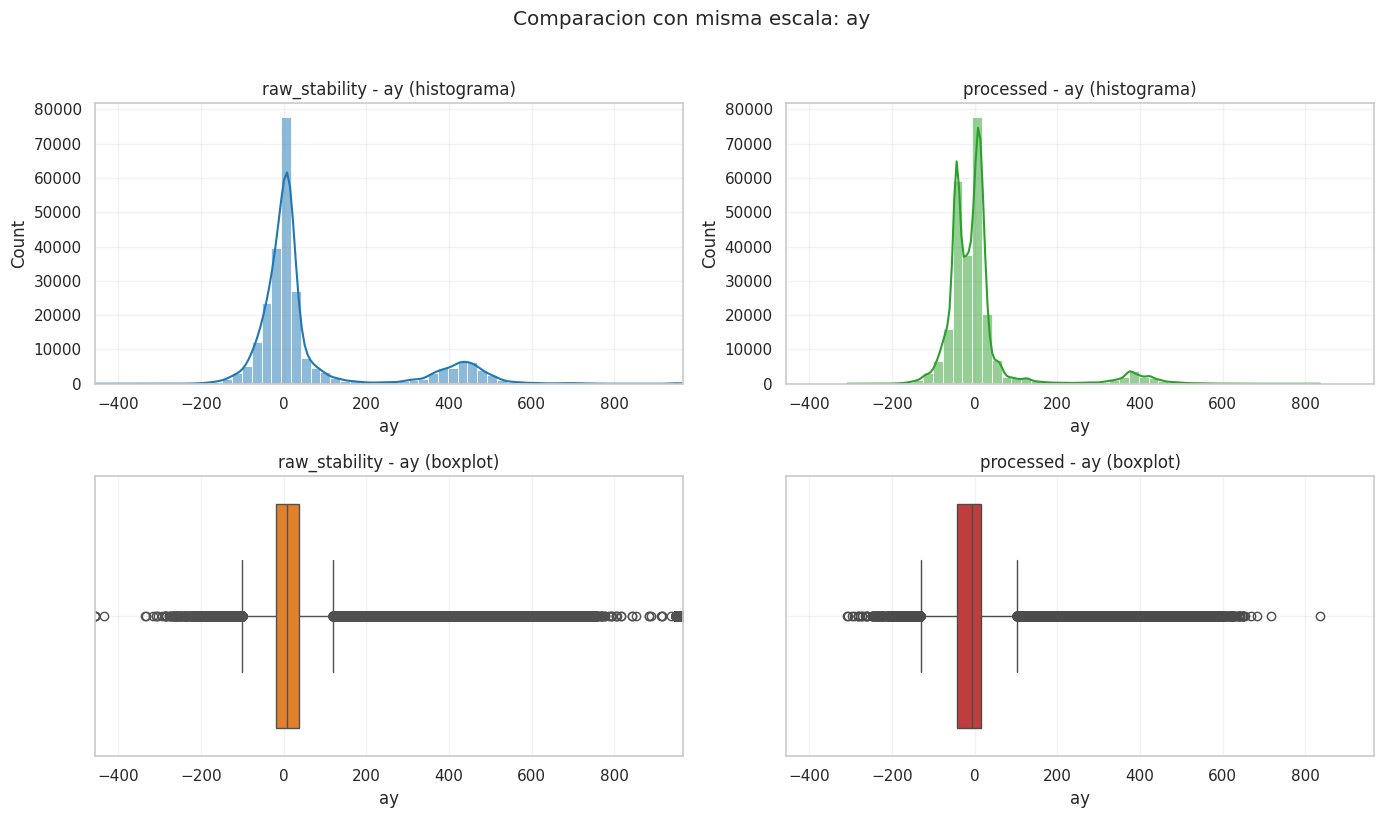

[ay] escalas igualadas | x_range=(-455.9100, 966.0000) | y_hist_max=81788.70
[raw_stability] invalid_pct=0.00% outlier_pct=19.50%
[processed] invalid_pct=0.00% outlier_pct=7.76%
Variable: az (RAW STABILITY vs PROCESSED, misma escala)


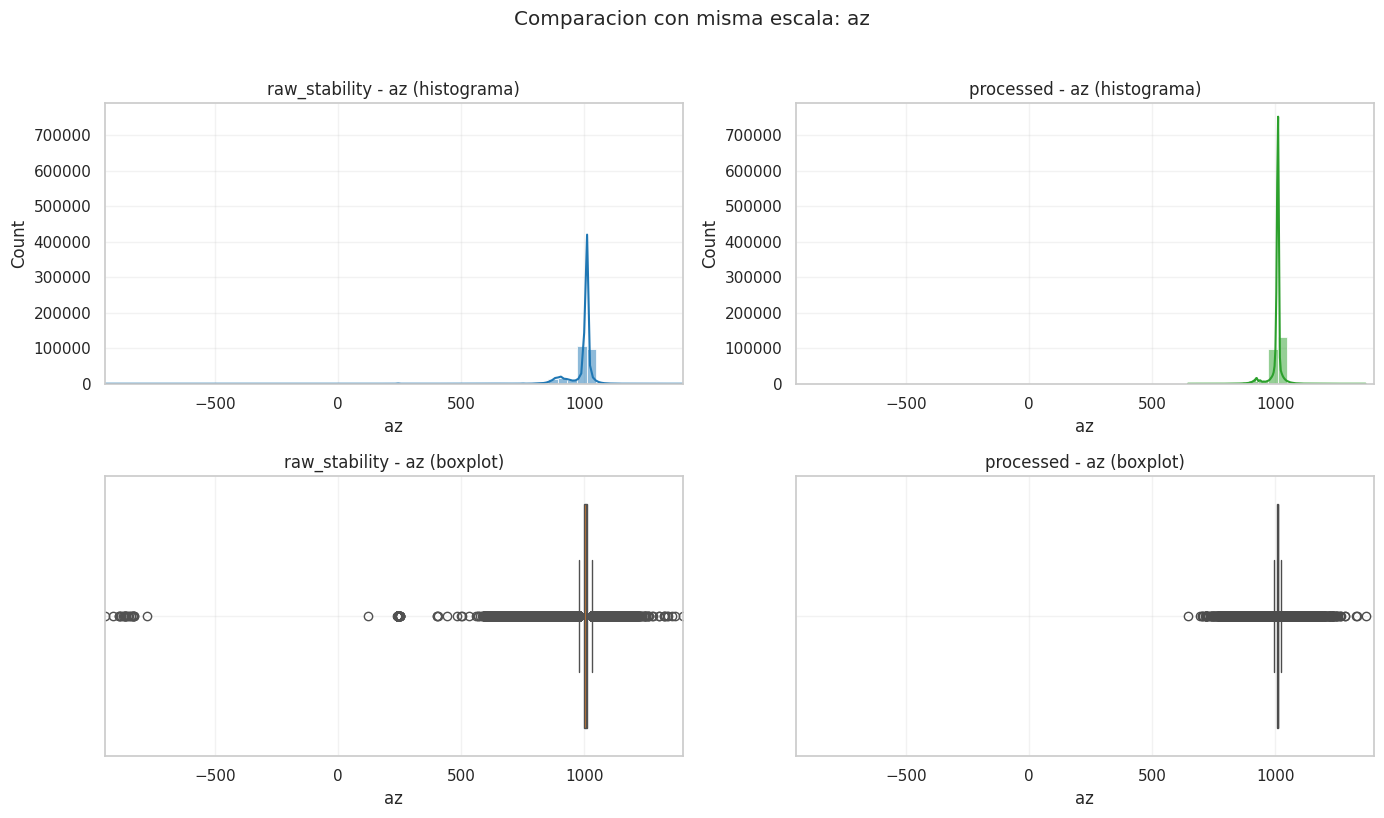

[az] escalas igualadas | x_range=(-948.1800, 1400.5600) | y_hist_max=789157.91
[raw_stability] invalid_pct=0.00% outlier_pct=22.44%
[processed] invalid_pct=0.00% outlier_pct=18.01%
Variable: roll (RAW STABILITY vs PROCESSED, misma escala)


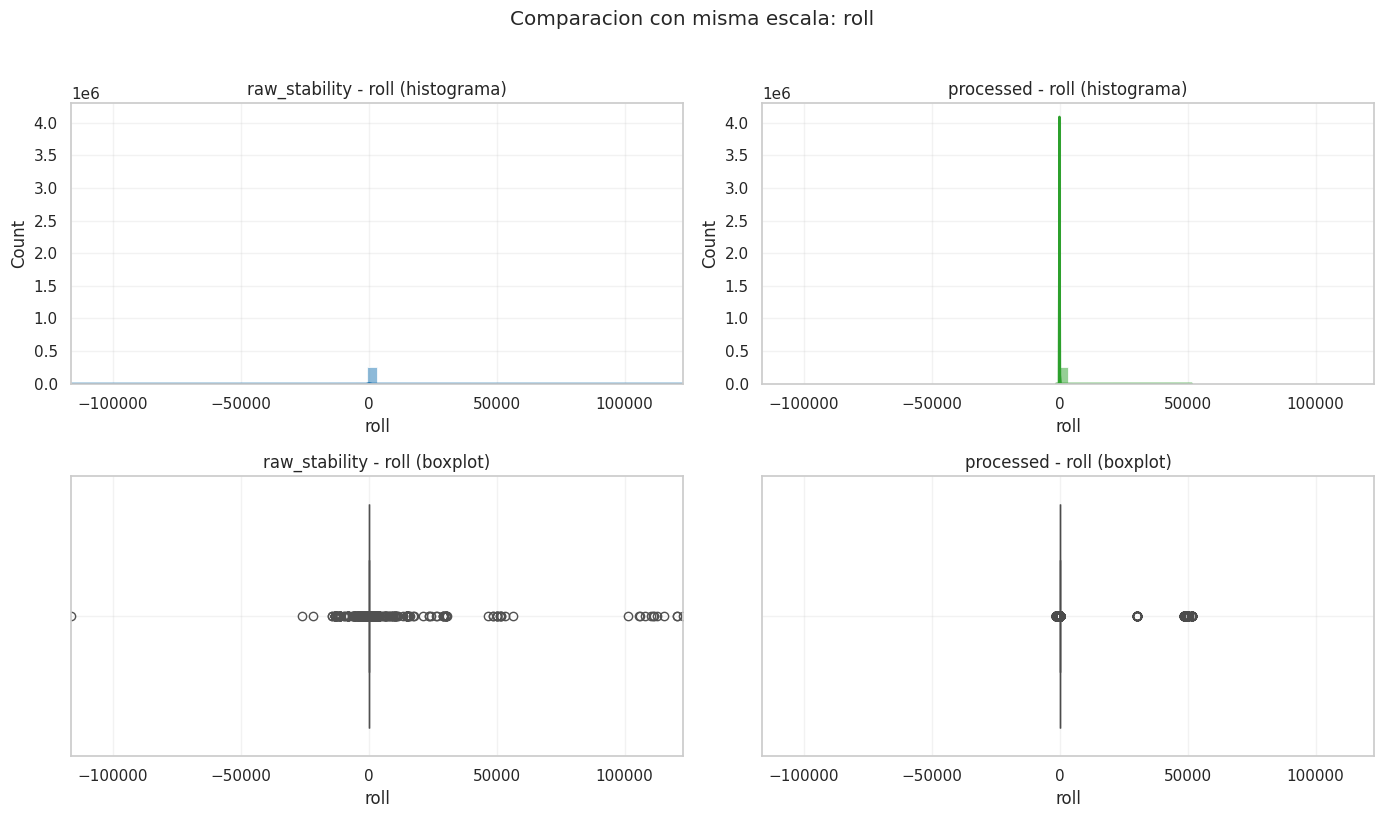

[roll] escalas igualadas | x_range=(-116259.6100, 122846.2500) | y_hist_max=4296249.10
[raw_stability] invalid_pct=0.00% outlier_pct=12.28%
[processed] invalid_pct=0.00% outlier_pct=13.06%
Variable: pitch (RAW STABILITY vs PROCESSED, misma escala)


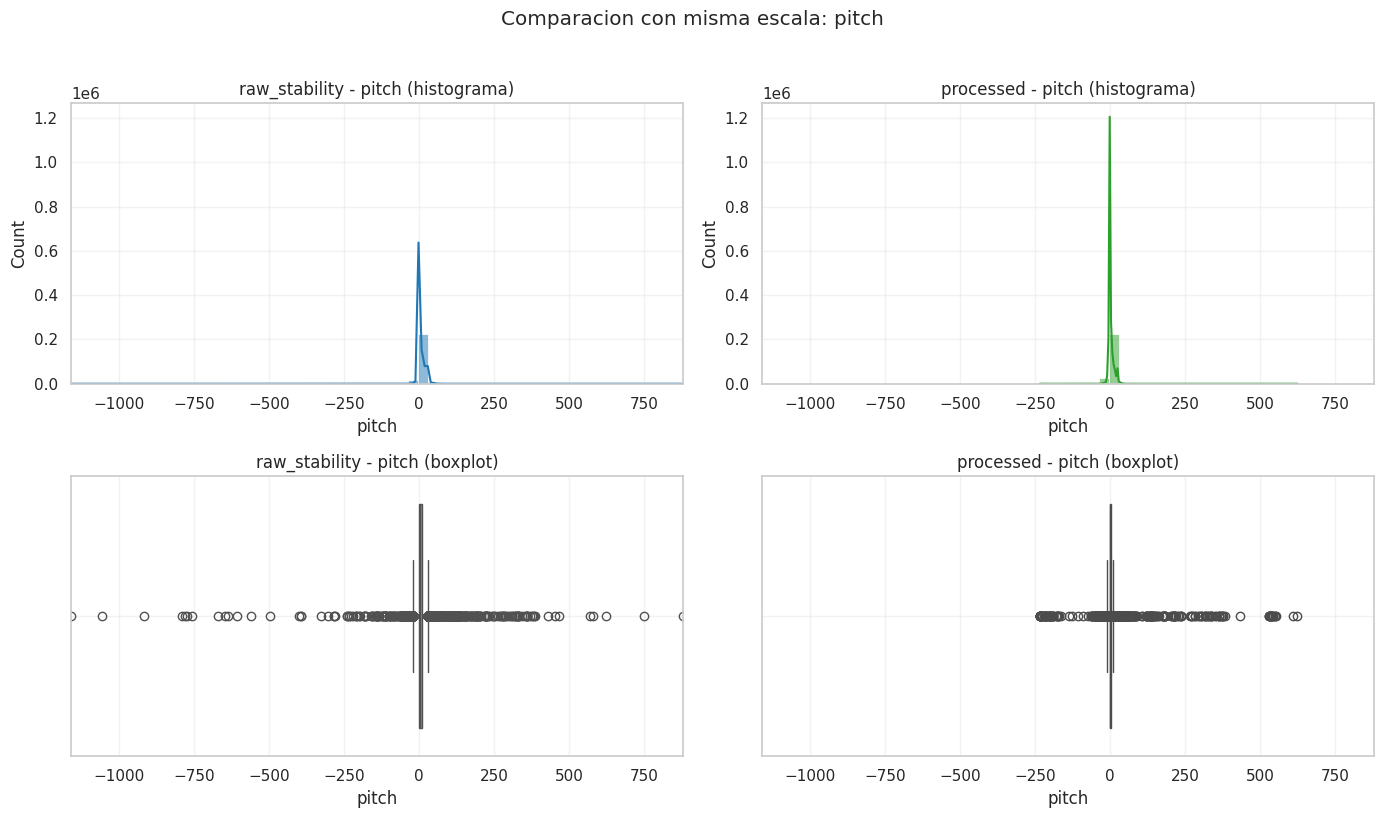

[pitch] escalas igualadas | x_range=(-1159.9400, 878.7700) | y_hist_max=1266109.35
[raw_stability] invalid_pct=0.00% outlier_pct=4.79%
[processed] invalid_pct=0.00% outlier_pct=13.32%
Variable: yaw (RAW STABILITY vs PROCESSED, misma escala)


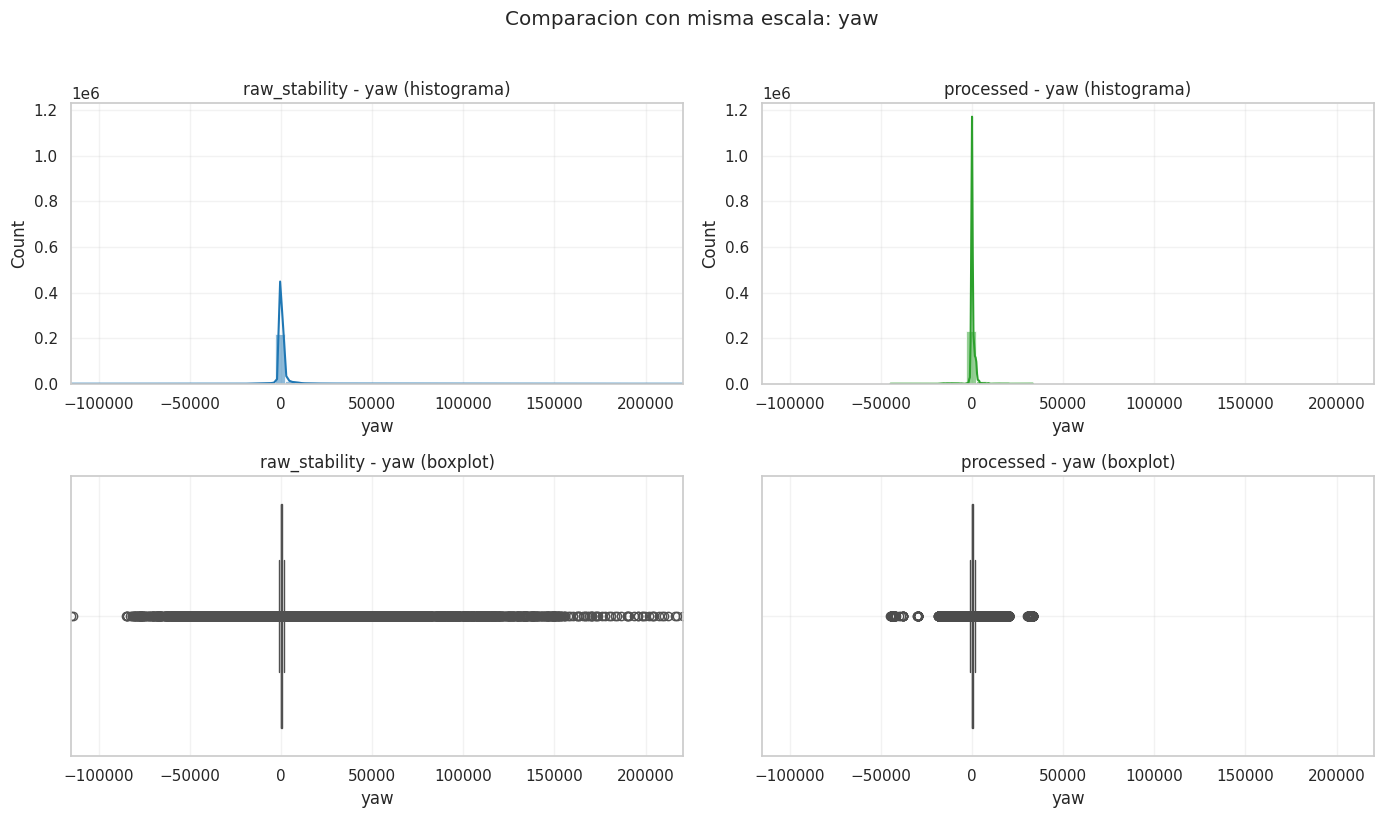

[yaw] escalas igualadas | x_range=(-115111.3500, 220467.3000) | y_hist_max=1229712.60
[raw_stability] invalid_pct=0.00% outlier_pct=16.01%
[processed] invalid_pct=0.00% outlier_pct=13.97%
Variable: si (RAW STABILITY vs PROCESSED, misma escala)


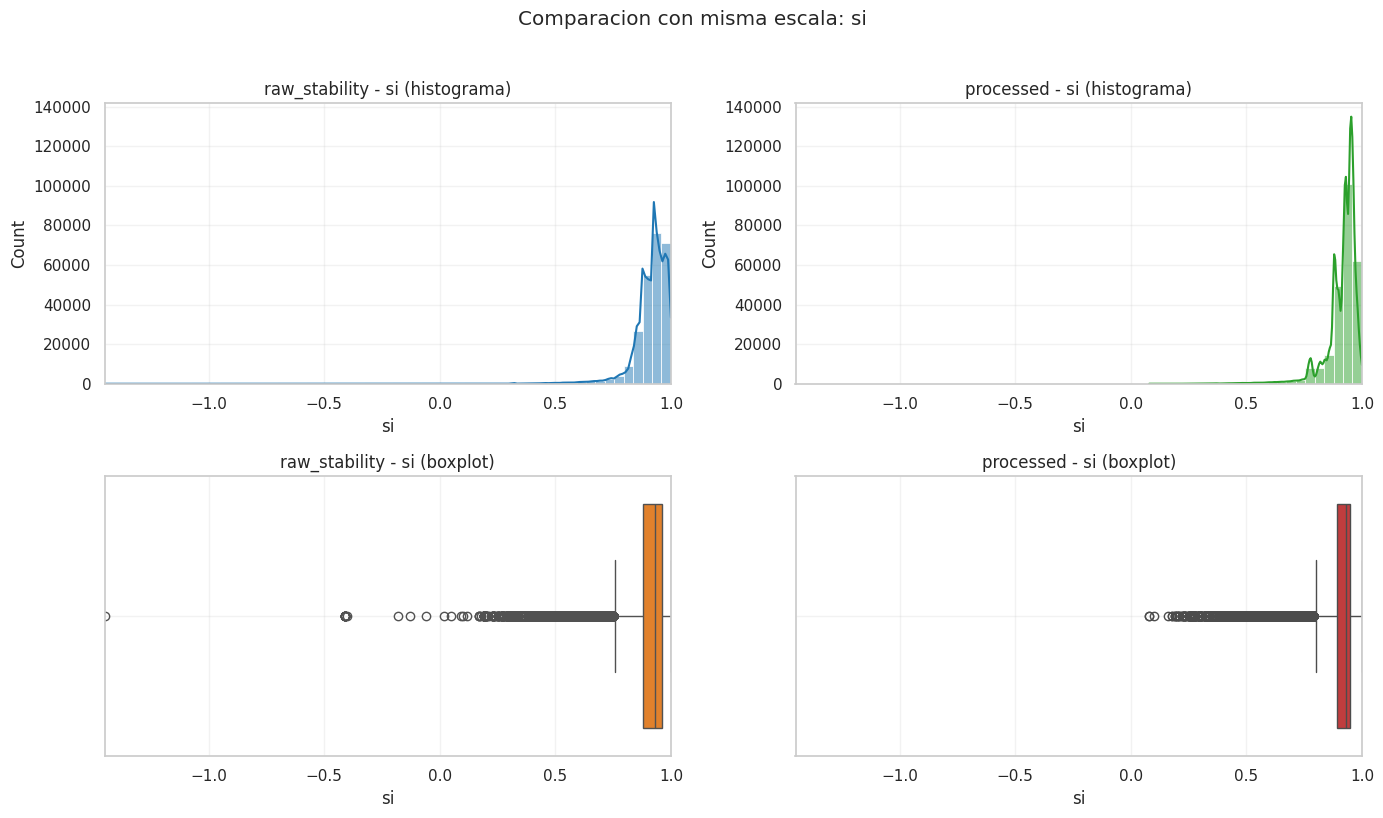

[si] escalas igualadas | x_range=(-1.4500, 1.0000) | y_hist_max=141729.11
[raw_stability] invalid_pct=0.00% outlier_pct=3.39%
[processed] invalid_pct=0.00% outlier_pct=6.11%
Variable: accmag (RAW STABILITY vs PROCESSED, misma escala)


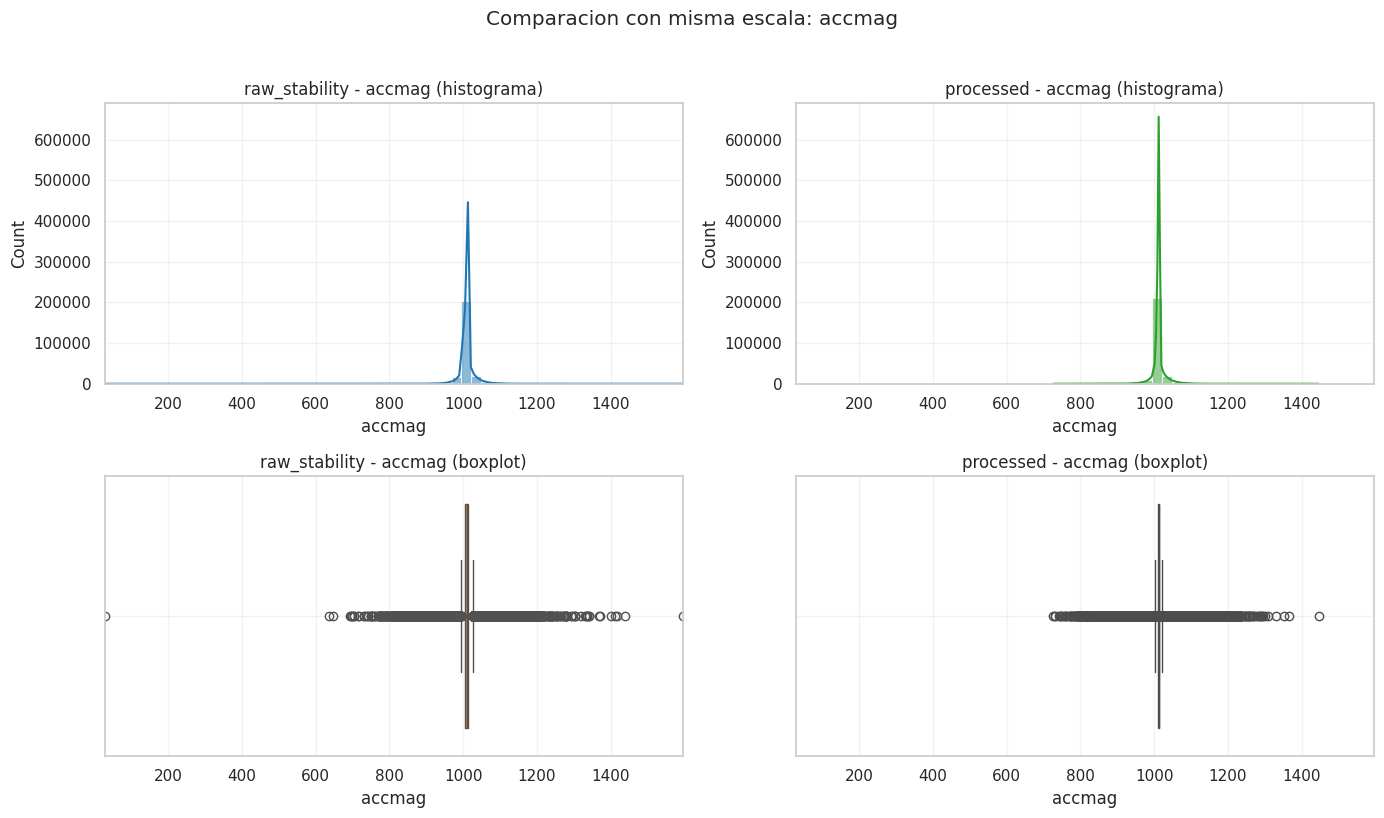

[accmag] escalas igualadas | x_range=(27.8300, 1596.2700) | y_hist_max=689029.62
[raw_stability] invalid_pct=0.00% outlier_pct=14.85%
[processed] invalid_pct=0.00% outlier_pct=19.14%
Variable: velocidad_kmh (RAW STABILITY vs PROCESSED, misma escala)
[velocidad_kmh] comparacion omitida: columna no encontrada en uno de los datasets (raw_stability=None, processed=speed_kmh)

Resumen RAW


,stage,variable,column_used,rows,valid_rows,invalid_pct,outlier_pct_over_valid,mean,std,min,max
0,raw_stability,ax,ax,37947071,37947069,0.000005,5.534095,2.296710e+30,9.982913e+33,-1.966528e+29,4.348400e+37
1,raw_stability,gx,gx,37947071,37947069,0.000005,15.237380,-7.645973e+01,2.419786e+03,-1.436360e+05,1.433119e+05
2,raw_stability,gz,gz,37947071,37947069,0.000005,24.344299,4.705640e+02,4.724401e+03,-1.591209e+05,1.979206e+05
3,raw_stability,gy,gy,37947071,37947067,0.000011,18.153864,5.837961e+01,3.390137e+03,-1.455093e+05,1.442918e+05
4,raw_stability,ay,ay,37947071,37947014,0.000150,19.499782,6.623123e+01,1.678421e+02,-1.002230e+03,1.171690e+03
5,raw_stability,az,az,37947071,37947066,0.000013,22.443100,1.063548e+17,8.999283e+19,-1.008820e+03,7.614815e+22
6,raw_stability,roll,roll,37947071,37947070,0.000003,12.282719,1.250007e+01,9.579827e+02,-1.190893e+05,1.287748e+05
7,raw_stability,pitch,pitch,37947071,37947070,0.000003,4.788343,5.766009e+00,1.407452e+01,-1.276980e+03,1.910000e+03
8,raw_stability,yaw,yaw,37947071,37947067,0.000011,16.005806,1.228546e+03,1.543869e+04,-1.233578e+05,6.399485e+07
9,raw_stability,si,si,37947071,37947068,0.000008,3.385410,9.179614e-01,2.014304e+01,-8.969000e+01,1.174350e+05



Resumen PROCESSED


,stage,variable,column_used,rows,valid_rows,invalid_pct,outlier_pct_over_valid,mean,std,min,max
0,processed,ax,ax,2022176,2022176,0.0,6.213208,-44.891109,55.261662,-588.53,462.14
1,processed,gx,gx,2022176,2022176,0.0,20.729452,-27.661072,2045.486960,-120638.35,109873.14
2,processed,gz,gz,2022176,2022176,0.0,27.887088,135.852841,3795.596254,-80366.65,92192.02
3,processed,gy,gy,2022176,2022176,0.0,20.134400,2.994701,2361.578763,-72282.09,91179.73
4,processed,ay,ay,2022176,2022176,0.0,7.763815,10.268408,103.439602,-330.50,835.46
5,processed,az,az,2022176,2022176,0.0,18.013862,1004.715857,26.652385,505.57,1379.70
6,processed,roll,roll,2022176,2022176,0.0,13.063452,20.348469,940.290603,-1381.51,51686.36
7,processed,pitch,pitch,2022176,2022176,0.0,13.319365,1.516618,10.202895,-246.08,623.87
8,processed,yaw,yaw,2022176,2022176,0.0,13.970545,274.218710,2306.507545,-44673.22,33410.91
9,processed,si,si,2022176,2022176,0.0,6.110695,0.913102,0.071062,0.08,1.00


In [5]:
# Graficas de distribucion por variable (fase 2)

raw_summaries = []
processed_summaries = []

for var_name, aliases in BASE_VARIABLES.items():
    print("=" * 90)
    print(f"Variable: {var_name} (RAW STABILITY vs PROCESSED, misma escala)")
    raw_sum, processed_sum = plot_variable_comparison_same_scale(
        raw_stability_df,
        processed_df,
        var_name,
        aliases,
        "raw_stability",
        "processed",
    )
    raw_summaries.append(raw_sum)
    processed_summaries.append(processed_sum)

raw_summary_df = pd.DataFrame(raw_summaries)
processed_summary_df = pd.DataFrame(processed_summaries)

print("\nResumen RAW")
display(raw_summary_df)
print("\nResumen PROCESSED")
display(processed_summary_df)


## Fase 3 - Evaluacion de map-matching

Se calcula:
- Porcentaje de filas perdidas de `processed-data` a `map-matched`.
- Calidad del ajuste por distancia entre coordenada original y coordenada ajustada.
- Distribuciones por variable en la salida map-matched.


/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)
/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)
/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)
/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)
/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)
/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)


mapmatched_df shape: (2022176, 70)


/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  return int(pd.read_csv(path).shape[0])
/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  return int(pd.read_csv(path).shape[0])
/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  return int(pd.read_csv(path).shape[0])
/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  return int(pd.read_csv(path).shape[0])
/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  return int(pd.read_csv(path).shape[0])
/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (36) have mixed types. Speci

Perdida procesado -> map-matched: before=2,022,176 after=2,022,176 lost=0 loss_pct=0.00%


,stage,key,before_rows,after_rows,lost_rows,loss_pct
0,processed_vs_mapmatched,DOBACK023_20251012,381545,381545,0,0.0
1,processed_vs_mapmatched,DOBACK023_20251110,11286,11286,0,0.0
2,processed_vs_mapmatched,DOBACK024_20250929,57560,57560,0,0.0
3,processed_vs_mapmatched,DOBACK024_20250930,1631,1631,0,0.0
4,processed_vs_mapmatched,DOBACK024_20251001,7556,7556,0,0.0
5,processed_vs_mapmatched,DOBACK024_20251003,32416,32416,0,0.0
6,processed_vs_mapmatched,DOBACK024_20251004,111,111,0,0.0
7,processed_vs_mapmatched,DOBACK024_20251005,8090,8090,0,0.0
8,processed_vs_mapmatched,DOBACK024_20251007,43691,43691,0,0.0
9,processed_vs_mapmatched,DOBACK024_20251008,2203,2203,0,0.0


Metricas de distancia map-matching (m)
count    2.022176e+06
mean     1.829589e+01
std      2.683973e+01
min      0.000000e+00
50%      1.406570e+00
90%      5.960130e+01
95%      7.429441e+01
99%      9.036765e+01
max      1.499753e+02
dtype: float64


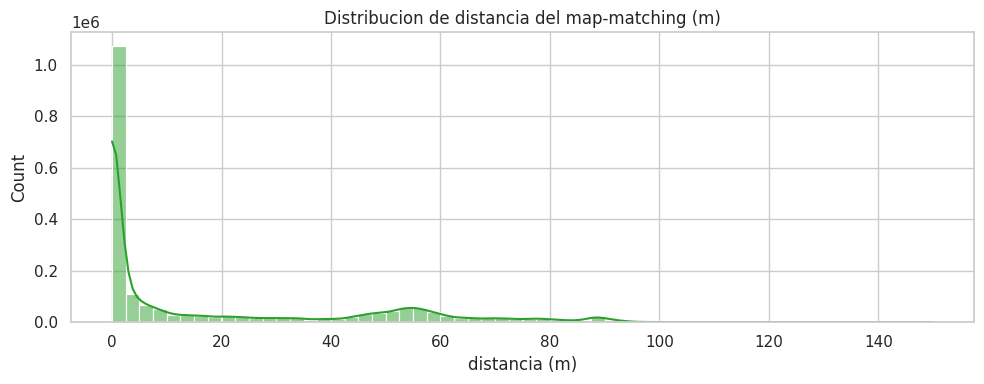

In [6]:
mapmatched_csv = list_csv_files(MAPMATCHED_DIR)
mapmatched_df = load_stage_dataframe(mapmatched_csv)

print(f"mapmatched_df shape: {mapmatched_df.shape}")

mapmatched_counts = {}
for fp in mapmatched_csv:
    key = file_key_from_name(fp.name)
    if key is None:
        continue
    mapmatched_counts[key] = mapmatched_counts.get(key, 0) + count_rows_csv(fp)

df_mm_cmp = compare_stage_counts(processed_counts, mapmatched_counts, "processed_vs_mapmatched")
print_global_loss(df_mm_cmp, "Perdida procesado -> map-matched")
display(df_mm_cmp.sort_values("loss_pct", ascending=False).head(20))

# Metricas de distancia del map-matching
mm_dist_series = pd.Series(dtype=float)
if not mapmatched_df.empty:
    if all(c in mapmatched_df.columns for c in ["lat_raw", "lon_raw", "lat", "lon"]):
        lat1 = pd.to_numeric(mapmatched_df["lat_raw"], errors="coerce")
        lon1 = pd.to_numeric(mapmatched_df["lon_raw"], errors="coerce")
        lat2 = pd.to_numeric(mapmatched_df["lat"], errors="coerce")
        lon2 = pd.to_numeric(mapmatched_df["lon"], errors="coerce")
        ok = lat1.notna() & lon1.notna() & lat2.notna() & lon2.notna()
        mm_dist_series = pd.Series(haversine_m(lat1[ok], lon1[ok], lat2[ok], lon2[ok]))
    elif "dist_to_road_m" in mapmatched_df.columns:
        mm_dist_series = pd.to_numeric(mapmatched_df["dist_to_road_m"], errors="coerce").dropna()

if len(mm_dist_series) > 0:
    print("Metricas de distancia map-matching (m)")
    print(mm_dist_series.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    plt.figure(figsize=(10, 4))
    sns.histplot(mm_dist_series, bins=60, kde=True, color="#2ca02c")
    plt.title("Distribucion de distancia del map-matching (m)")
    plt.xlabel("distancia (m)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas suficientes para calcular metrica de distancia de map-matching")


Variable: ax (MAP-MATCHED)


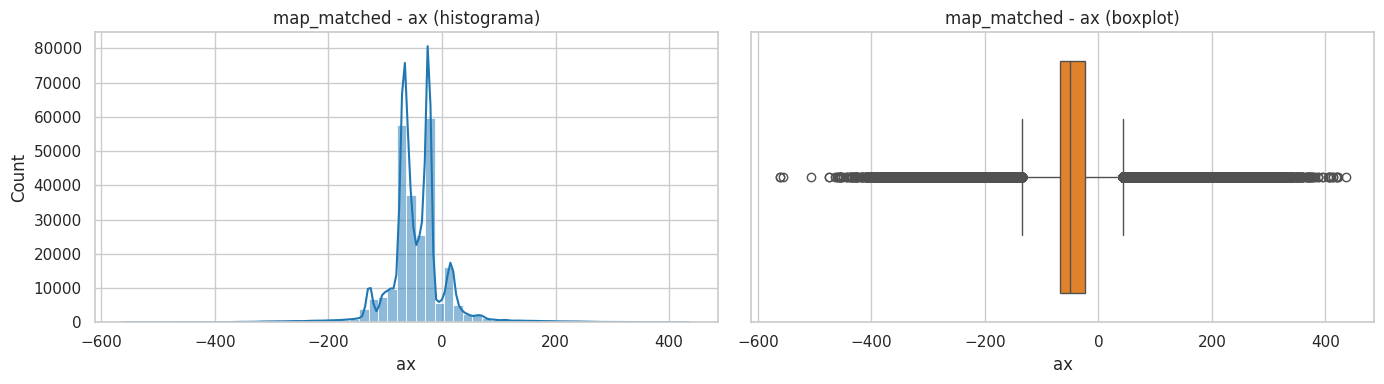

[map_matched] ax | col=ax | invalid_pct=0.00% | outlier_pct=6.21% | valid_rows=2022176
Variable: gx (MAP-MATCHED)


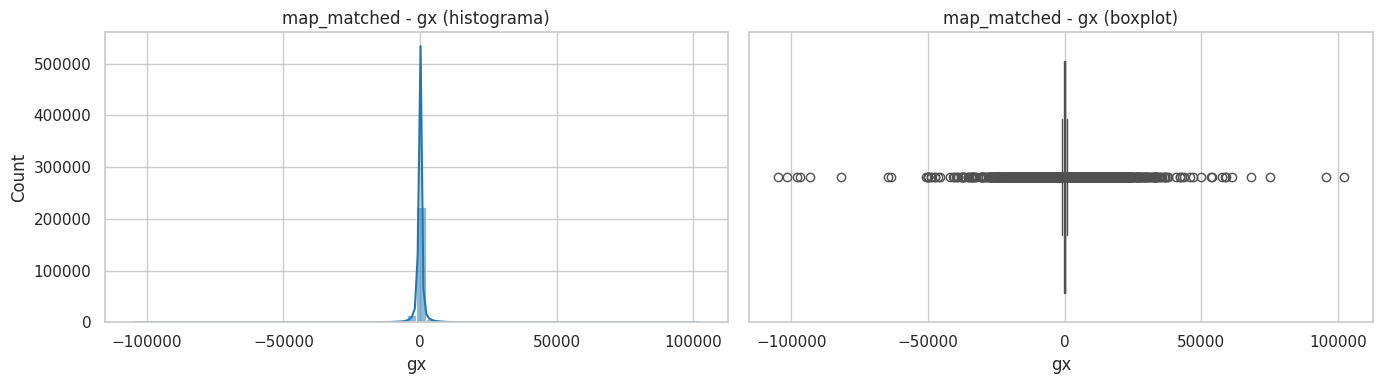

[map_matched] gx | col=gx | invalid_pct=0.00% | outlier_pct=20.73% | valid_rows=2022176
Variable: gz (MAP-MATCHED)


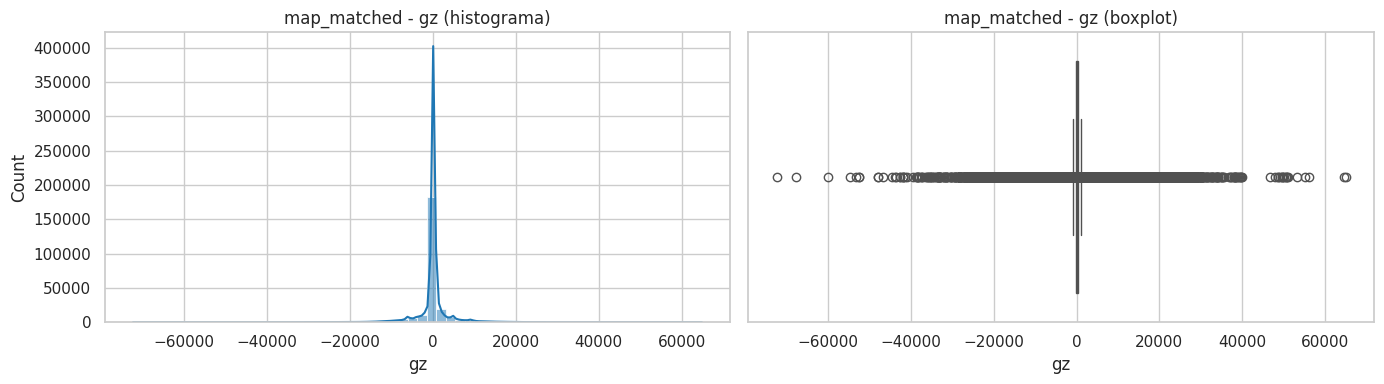

[map_matched] gz | col=gz | invalid_pct=0.00% | outlier_pct=27.89% | valid_rows=2022176
Variable: gy (MAP-MATCHED)


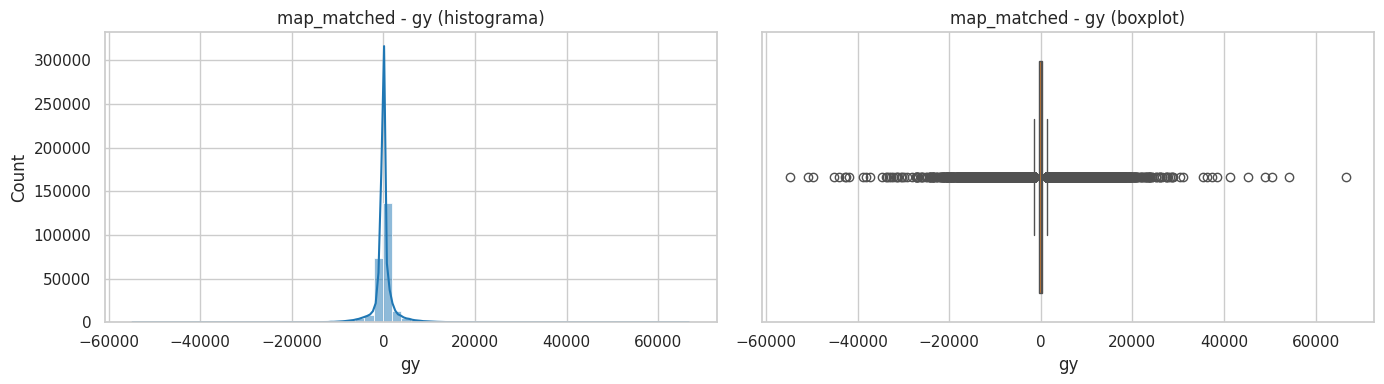

[map_matched] gy | col=gy | invalid_pct=0.00% | outlier_pct=20.13% | valid_rows=2022176
Variable: ay (MAP-MATCHED)


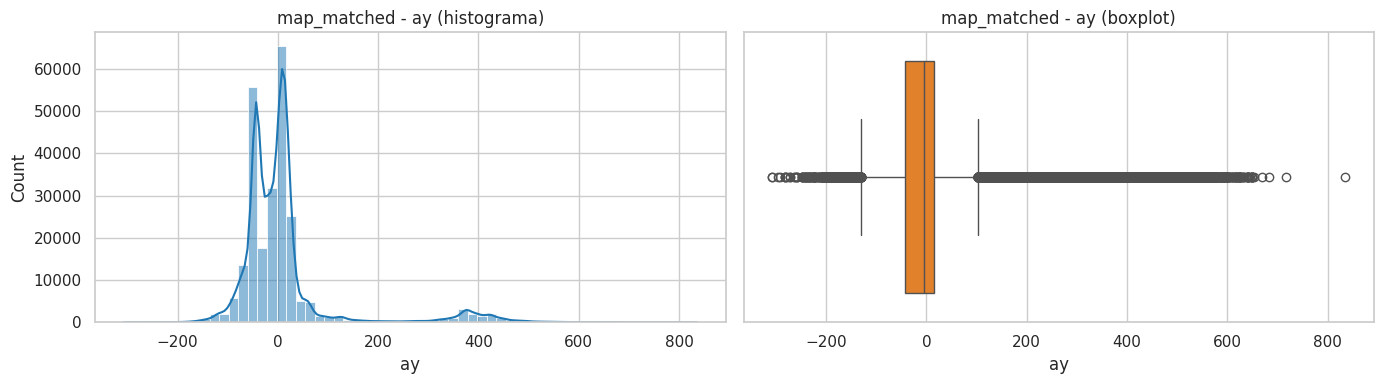

[map_matched] ay | col=ay | invalid_pct=0.00% | outlier_pct=7.76% | valid_rows=2022176
Variable: az (MAP-MATCHED)


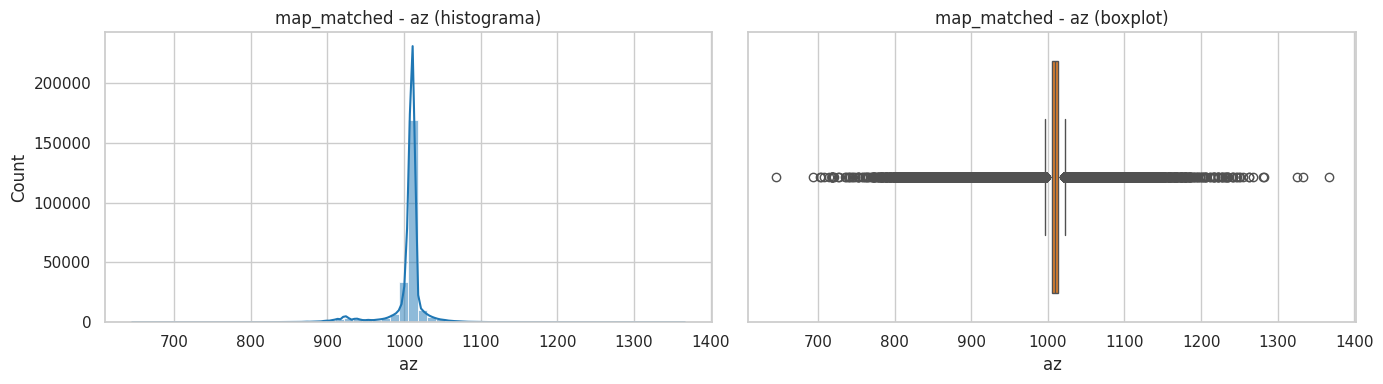

[map_matched] az | col=az | invalid_pct=0.00% | outlier_pct=18.01% | valid_rows=2022176
Variable: roll (MAP-MATCHED)


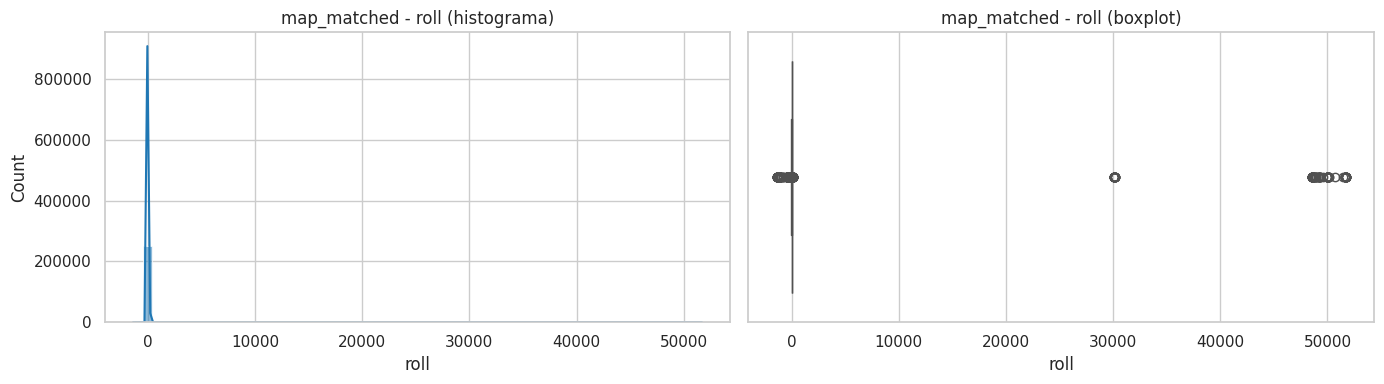

[map_matched] roll | col=roll | invalid_pct=0.00% | outlier_pct=13.06% | valid_rows=2022176
Variable: pitch (MAP-MATCHED)


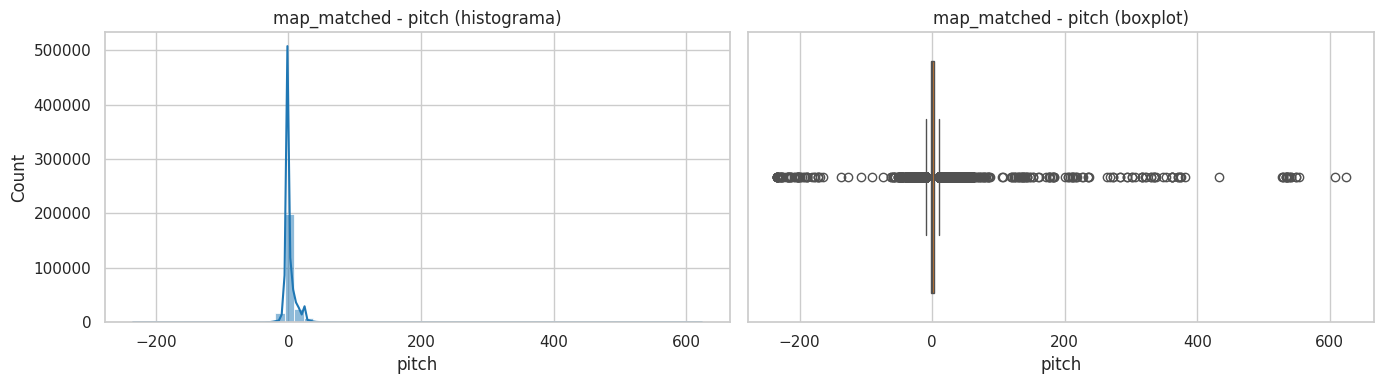

[map_matched] pitch | col=pitch | invalid_pct=0.00% | outlier_pct=13.32% | valid_rows=2022176
Variable: yaw (MAP-MATCHED)


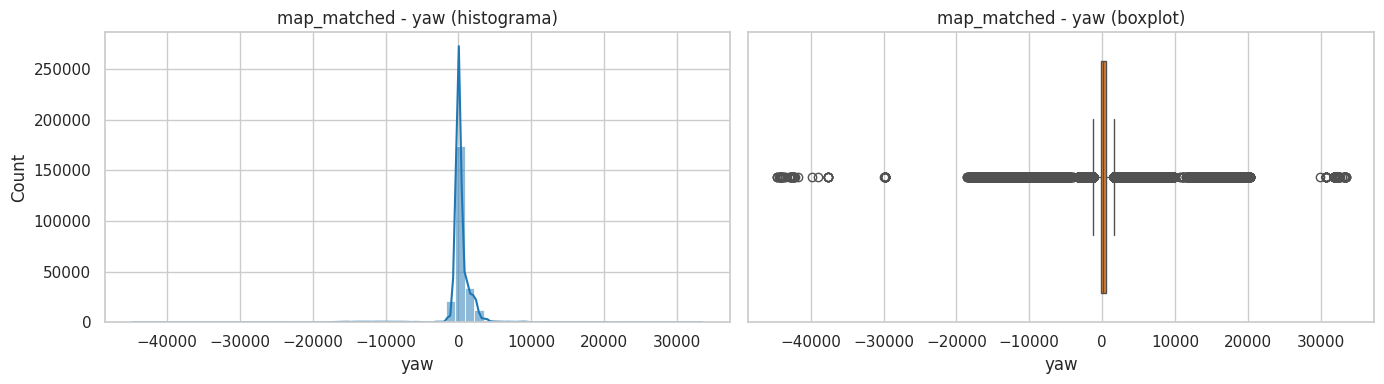

[map_matched] yaw | col=yaw | invalid_pct=0.00% | outlier_pct=13.97% | valid_rows=2022176
Variable: si (MAP-MATCHED)


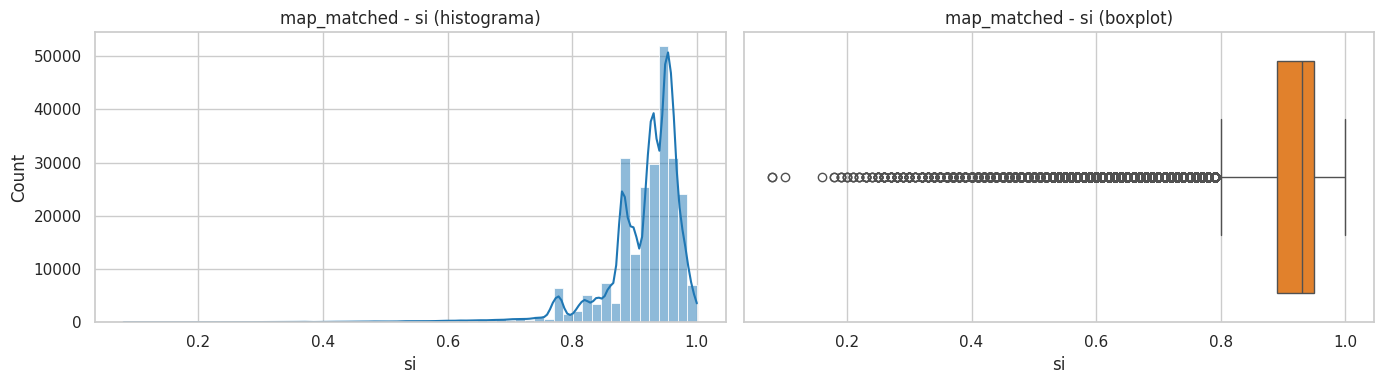

[map_matched] si | col=si | invalid_pct=0.00% | outlier_pct=6.11% | valid_rows=2022176
Variable: accmag (MAP-MATCHED)


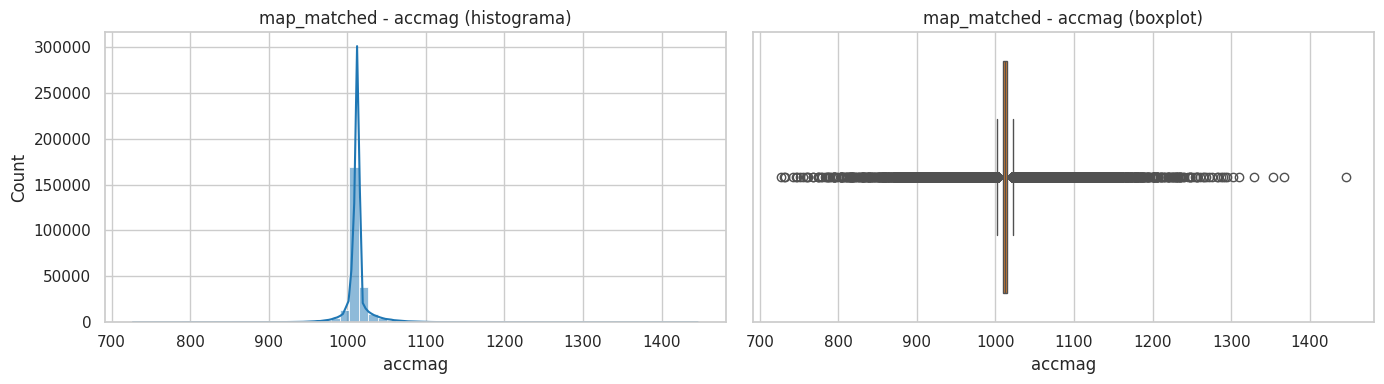

[map_matched] accmag | col=accmag | invalid_pct=0.00% | outlier_pct=19.14% | valid_rows=2022176
Variable: velocidad_kmh (MAP-MATCHED)


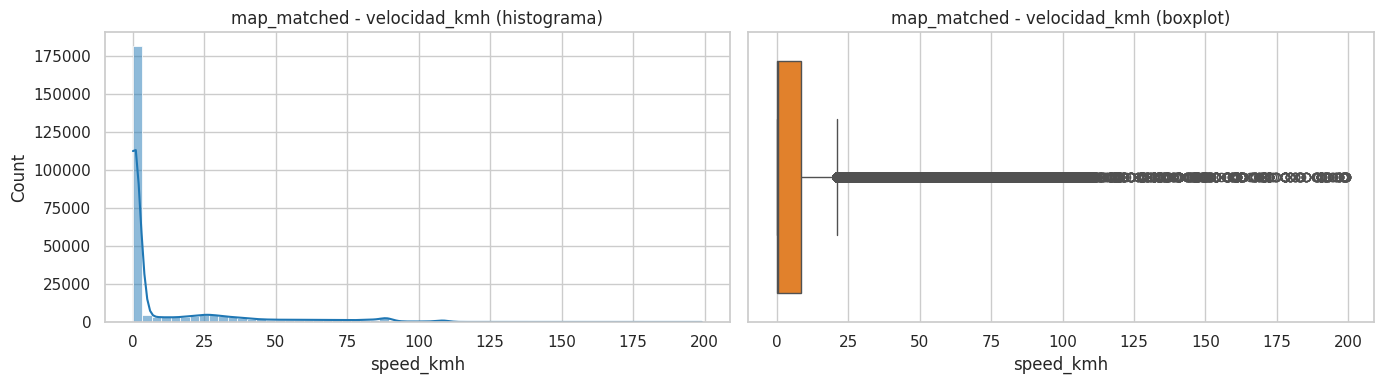

[map_matched] velocidad_kmh | col=speed_kmh | invalid_pct=0.00% | outlier_pct=20.41% | valid_rows=2022176

Resumen MAP-MATCHED


,stage,variable,column_used,rows,valid_rows,invalid_pct,outlier_pct_over_valid,mean,std,min,max
0,map_matched,ax,ax,2022176,2022176,0.0,6.213208,-44.891109,55.261662,-588.53,462.14
1,map_matched,gx,gx,2022176,2022176,0.0,20.729452,-27.661072,2045.486960,-120638.35,109873.14
2,map_matched,gz,gz,2022176,2022176,0.0,27.887088,135.852841,3795.596254,-80366.65,92192.02
3,map_matched,gy,gy,2022176,2022176,0.0,20.134400,2.994701,2361.578763,-72282.09,91179.73
4,map_matched,ay,ay,2022176,2022176,0.0,7.763815,10.268408,103.439602,-330.50,835.46
5,map_matched,az,az,2022176,2022176,0.0,18.013862,1004.715857,26.652385,505.57,1379.70
6,map_matched,roll,roll,2022176,2022176,0.0,13.063452,20.348469,940.290603,-1381.51,51686.36
7,map_matched,pitch,pitch,2022176,2022176,0.0,13.319365,1.516618,10.202895,-246.08,623.87
8,map_matched,yaw,yaw,2022176,2022176,0.0,13.970545,274.218710,2306.507545,-44673.22,33410.91
9,map_matched,si,si,2022176,2022176,0.0,6.110695,0.913102,0.071062,0.08,1.00


In [7]:
mapmatched_summaries = []
for var_name, aliases in BASE_VARIABLES.items():
    print("=" * 90)
    print(f"Variable: {var_name} (MAP-MATCHED)")
    mapmatched_summaries.append(plot_variable_distribution(mapmatched_df, var_name, aliases, "map_matched"))

mapmatched_summary_df = pd.DataFrame(mapmatched_summaries)
print("\nResumen MAP-MATCHED")
display(mapmatched_summary_df)


## Fase 4 - Evaluacion de feature extraction

Se calcula:
- Porcentaje de filas perdidas de `map-matched` a `featured`.
- Distribuciones por variable base + variables nuevas calculadas en feature extraction.
- Porcentaje de invalidos y outliers por variable.


In [8]:
featured_csv = list_csv_files(FEATURED_DIR)
featured_df = load_stage_dataframe(featured_csv)

print(f"featured_df shape: {featured_df.shape}")

featured_counts = {}
for fp in featured_csv:
    key = file_key_from_name(fp.name)
    if key is None:
        continue
    featured_counts[key] = featured_counts.get(key, 0) + count_rows_csv(fp)

df_feat_cmp = compare_stage_counts(mapmatched_counts, featured_counts, "mapmatched_vs_featured")
print_global_loss(df_feat_cmp, "Perdida map-matched -> featured")
display(df_feat_cmp.sort_values("loss_pct", ascending=False).head(20))


/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)
/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)
/tmp/ipykernel_280674/2161518351.py:335: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  dfi = pd.read_csv(fp)


featured_df shape: (1609105, 80)


/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  return int(pd.read_csv(path).shape[0])
/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  return int(pd.read_csv(path).shape[0])
/tmp/ipykernel_280674/2161518351.py:56: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  return int(pd.read_csv(path).shape[0])


Perdida map-matched -> featured: before=2,022,176 after=1,609,105 lost=413,071 loss_pct=20.43%


,stage,key,before_rows,after_rows,lost_rows,loss_pct
0,mapmatched_vs_featured,DOBACK023_20251012,381545,0,381545,100.000000
1,mapmatched_vs_featured,DOBACK023_20251110,11286,0,11286,100.000000
61,mapmatched_vs_featured,DOBACK028_20251002,8181,0,8181,100.000000
62,mapmatched_vs_featured,DOBACK028_20251003,102,0,102,100.000000
60,mapmatched_vs_featured,DOBACK028_20251001,593,0,593,100.000000
2,mapmatched_vs_featured,DOBACK024_20250929,57560,46196,11364,19.742877
3,mapmatched_vs_featured,DOBACK024_20250930,1631,1631,0,0.000000
7,mapmatched_vs_featured,DOBACK024_20251005,8090,8090,0,0.000000
4,mapmatched_vs_featured,DOBACK024_20251001,7556,7556,0,0.000000
5,mapmatched_vs_featured,DOBACK024_20251003,32416,32416,0,0.000000


Variable: ax (FEATURED)


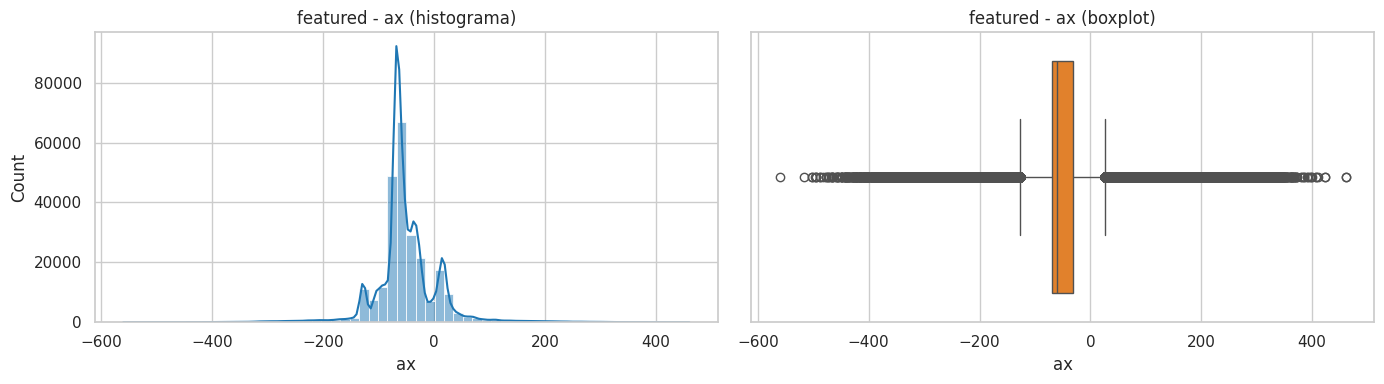

[featured] ax | col=ax | invalid_pct=0.00% | outlier_pct=11.44% | valid_rows=1609105
Variable: gx (FEATURED)


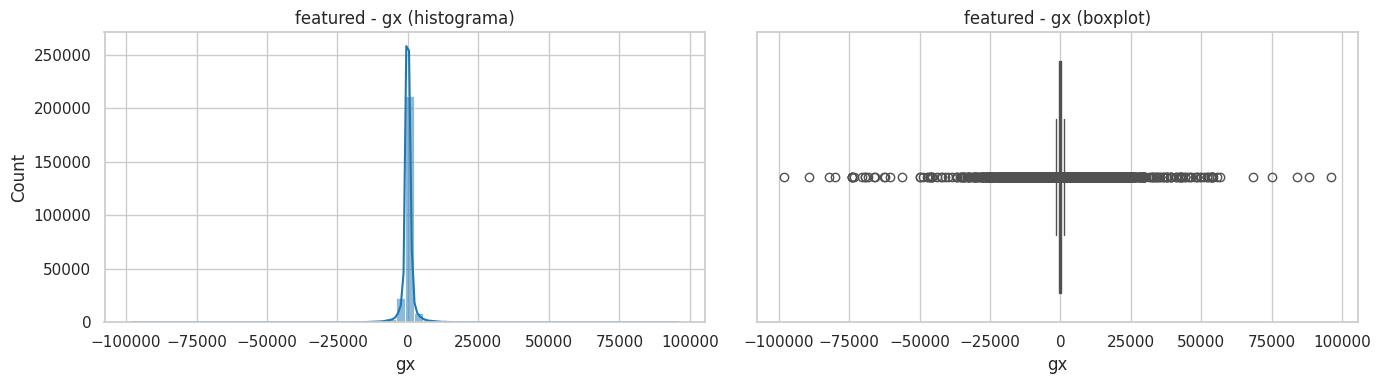

[featured] gx | col=gx | invalid_pct=0.00% | outlier_pct=16.14% | valid_rows=1609105
Variable: gz (FEATURED)


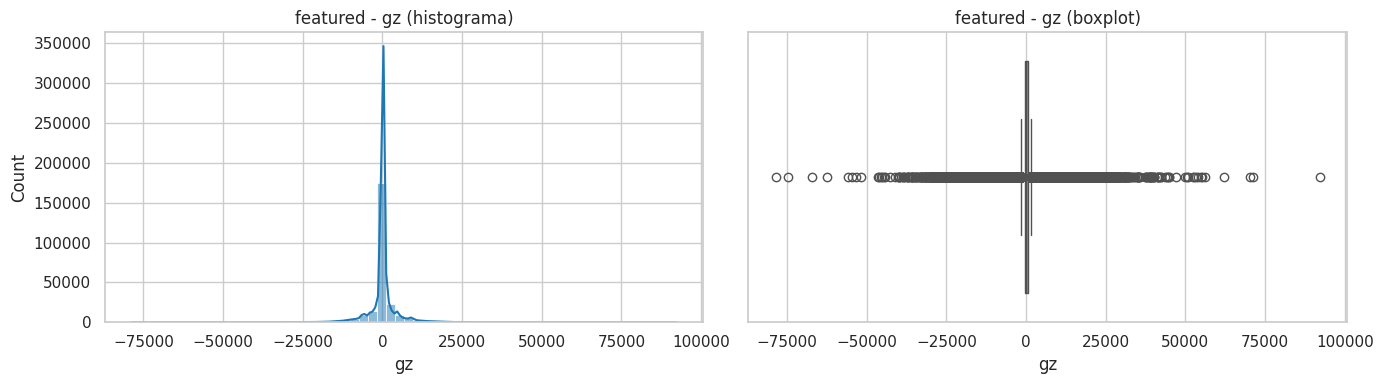

[featured] gz | col=gz | invalid_pct=0.00% | outlier_pct=27.50% | valid_rows=1609105
Variable: gy (FEATURED)


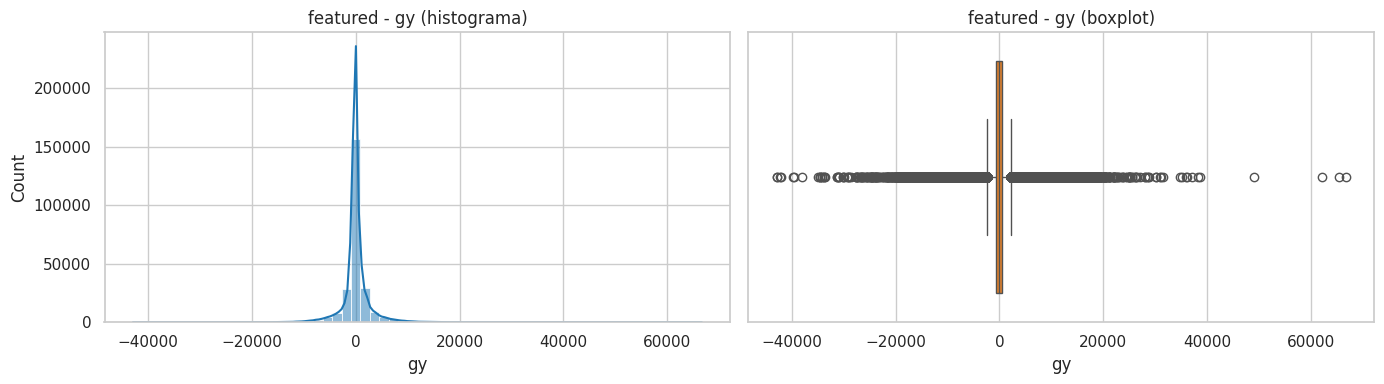

[featured] gy | col=gy | invalid_pct=0.00% | outlier_pct=17.01% | valid_rows=1609105
Variable: ay (FEATURED)


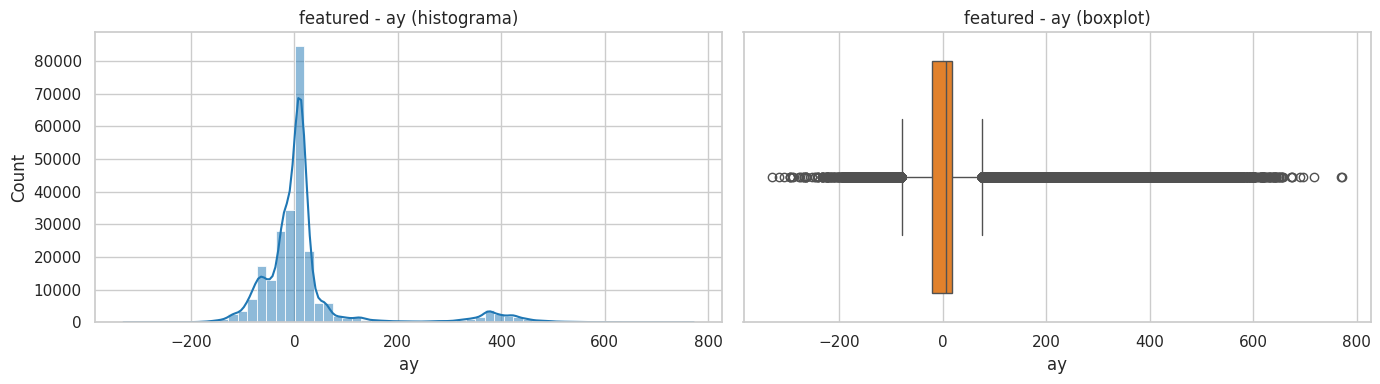

[featured] ay | col=ay | invalid_pct=0.00% | outlier_pct=14.82% | valid_rows=1609105
Variable: az (FEATURED)


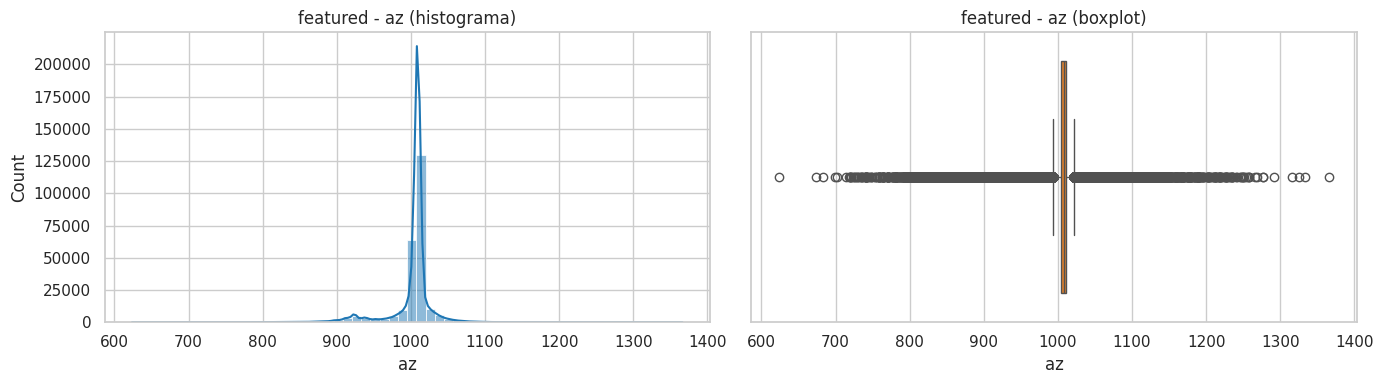

[featured] az | col=az | invalid_pct=0.00% | outlier_pct=21.32% | valid_rows=1609105
Variable: roll (FEATURED)


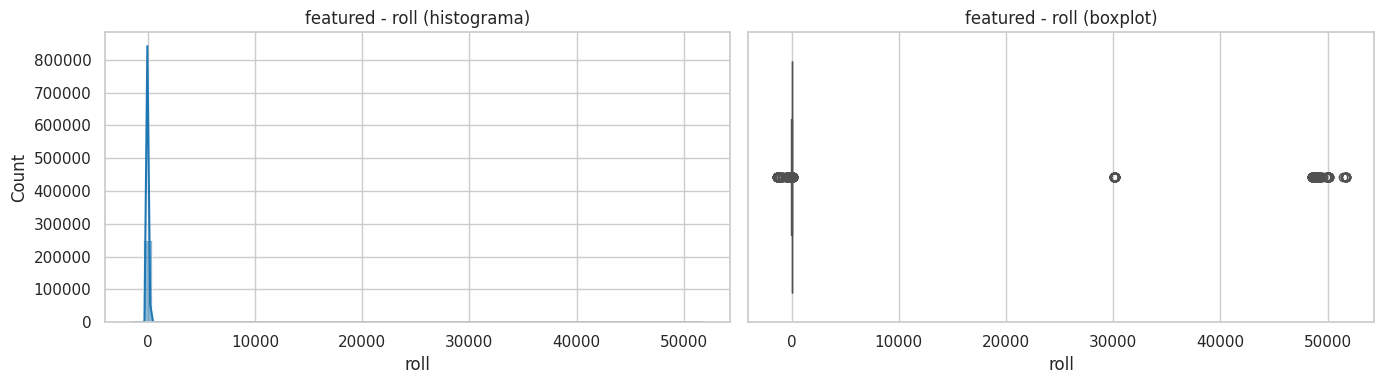

[featured] roll | col=roll | invalid_pct=0.00% | outlier_pct=10.87% | valid_rows=1609105
Variable: pitch (FEATURED)


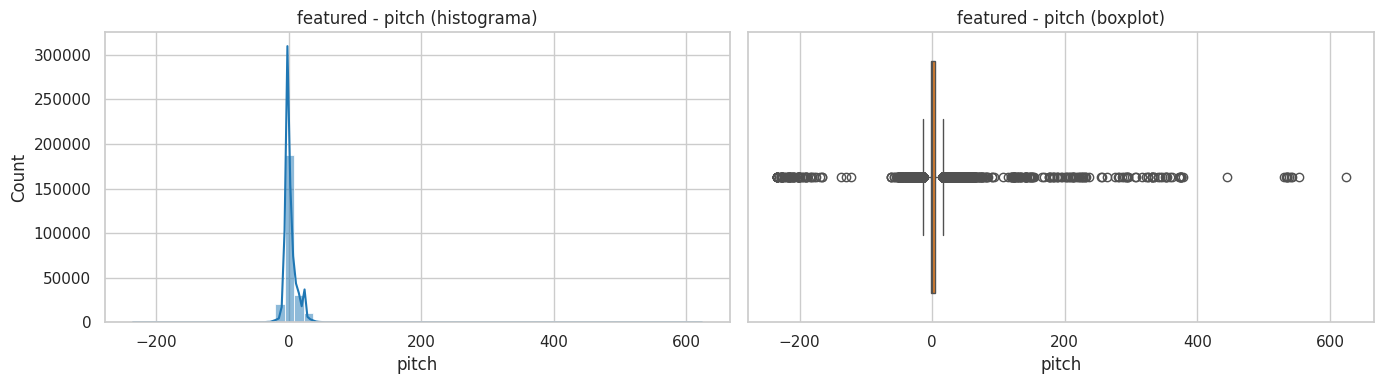

[featured] pitch | col=pitch | invalid_pct=0.00% | outlier_pct=9.52% | valid_rows=1609105
Variable: yaw (FEATURED)


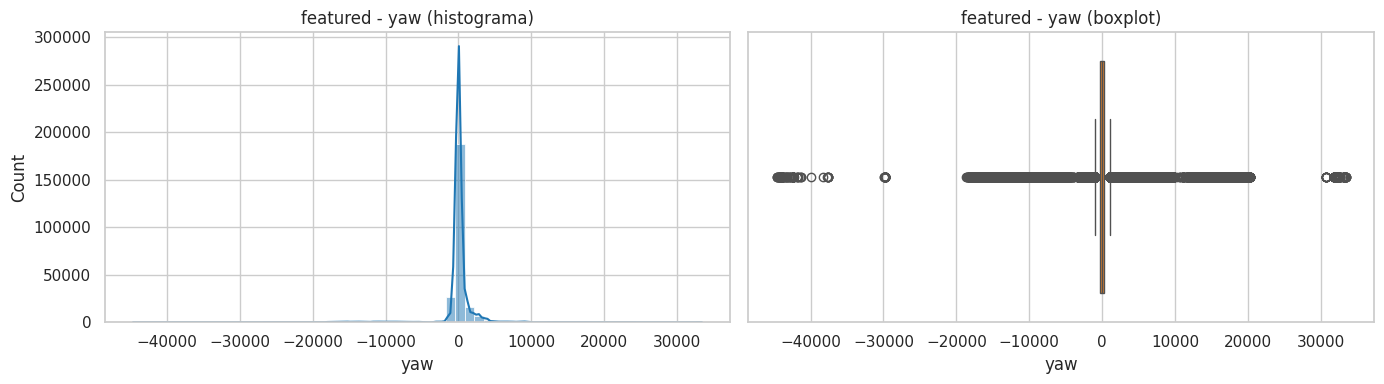

[featured] yaw | col=yaw | invalid_pct=0.00% | outlier_pct=13.47% | valid_rows=1609105
Variable: si (FEATURED)


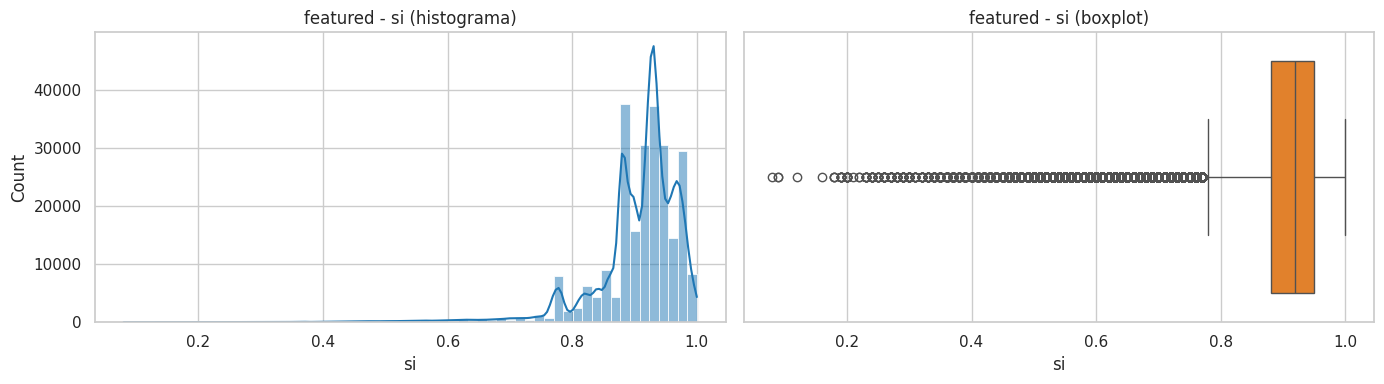

[featured] si | col=si | invalid_pct=0.00% | outlier_pct=5.21% | valid_rows=1609105
Variable: accmag (FEATURED)


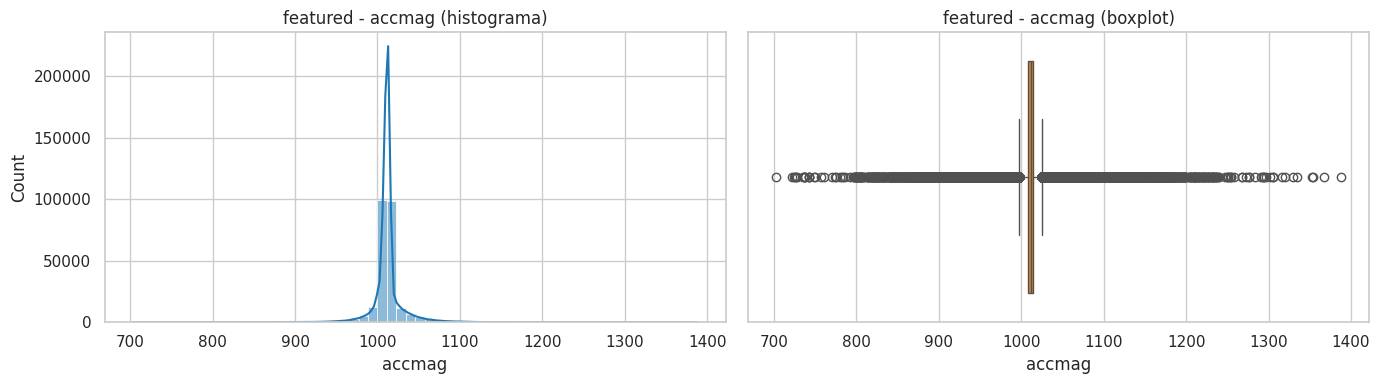

[featured] accmag | col=accmag | invalid_pct=0.00% | outlier_pct=18.19% | valid_rows=1609105
Variable: velocidad_kmh (FEATURED)


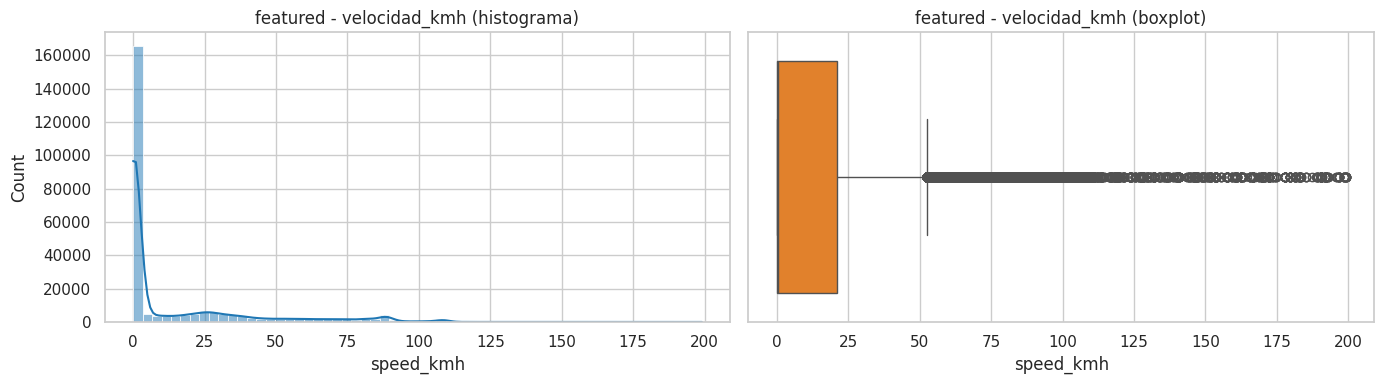

[featured] velocidad_kmh | col=speed_kmh | invalid_pct=0.00% | outlier_pct=10.78% | valid_rows=1609105
Variable: phi_lidar (FEATURED)


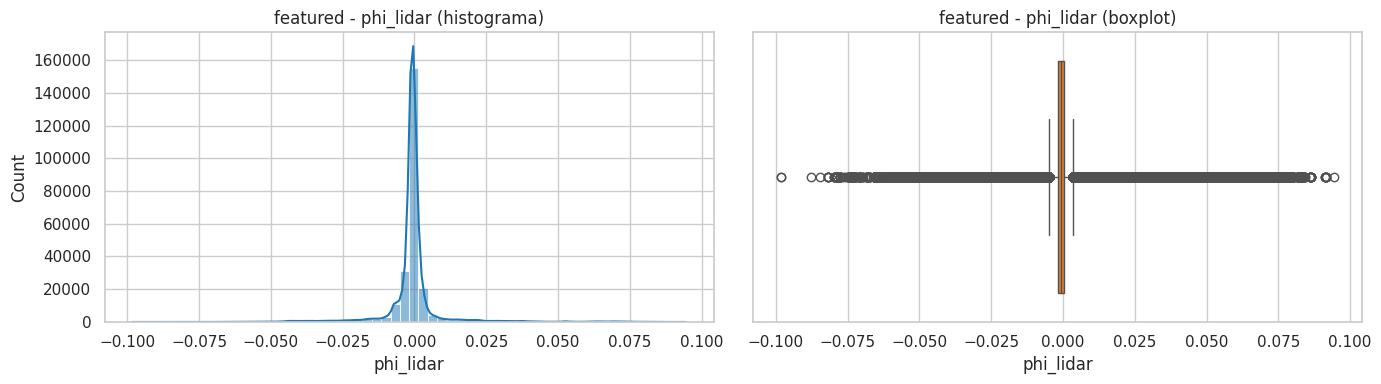

[featured] phi_lidar | col=phi_lidar | invalid_pct=0.09% | outlier_pct=18.58% | valid_rows=1607639
Variable: phi_lidar_deg (FEATURED)


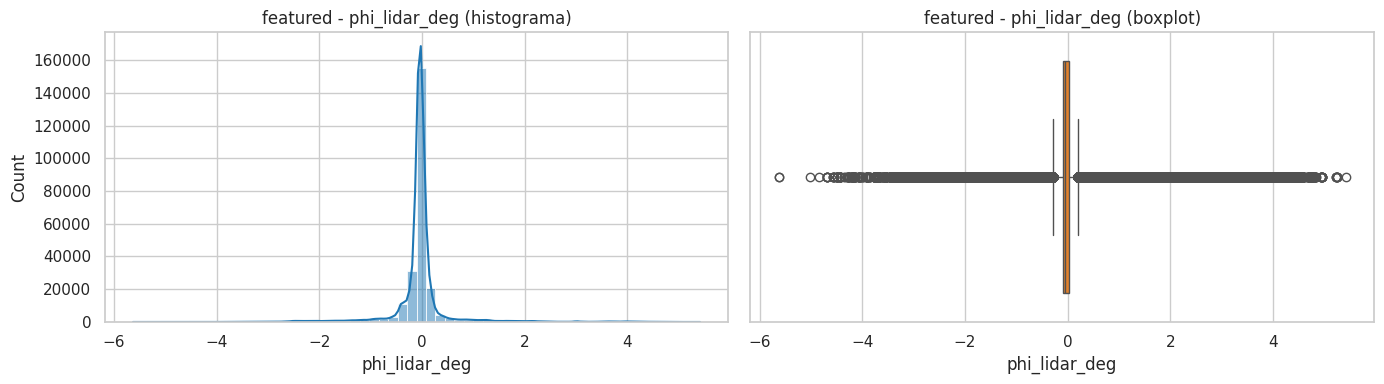

[featured] phi_lidar_deg | col=phi_lidar_deg | invalid_pct=0.09% | outlier_pct=18.58% | valid_rows=1607639
Variable: tri (FEATURED)


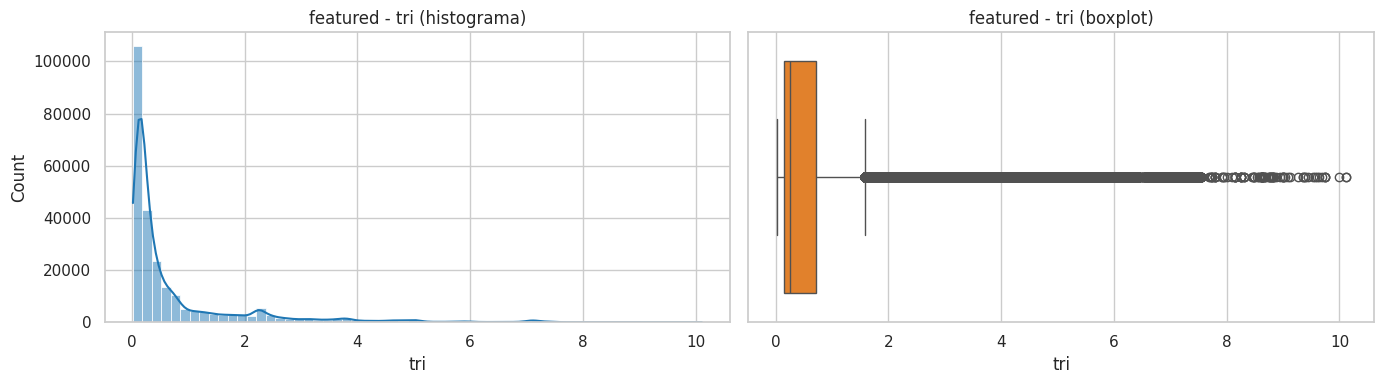

[featured] tri | col=tri | invalid_pct=0.09% | outlier_pct=14.68% | valid_rows=1607639
Variable: ruggedness (FEATURED)


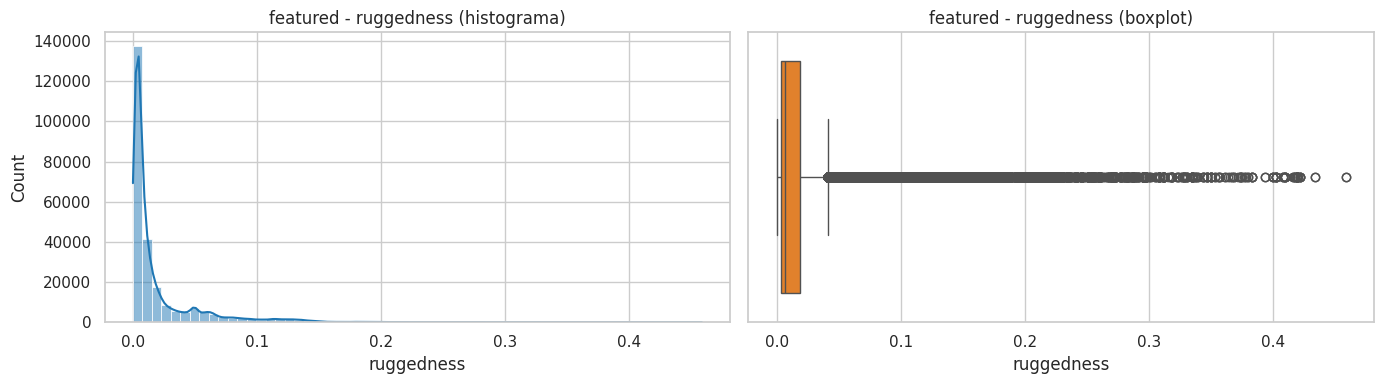

[featured] ruggedness | col=ruggedness | invalid_pct=0.09% | outlier_pct=14.87% | valid_rows=1607639
Variable: z_min (FEATURED)


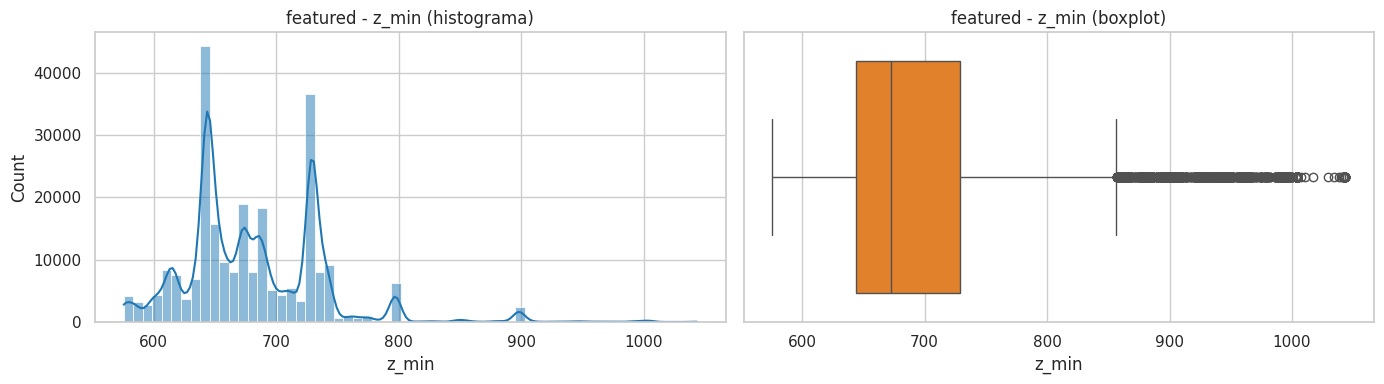

[featured] z_min | col=z_min | invalid_pct=0.09% | outlier_pct=1.59% | valid_rows=1607639
Variable: z_max (FEATURED)


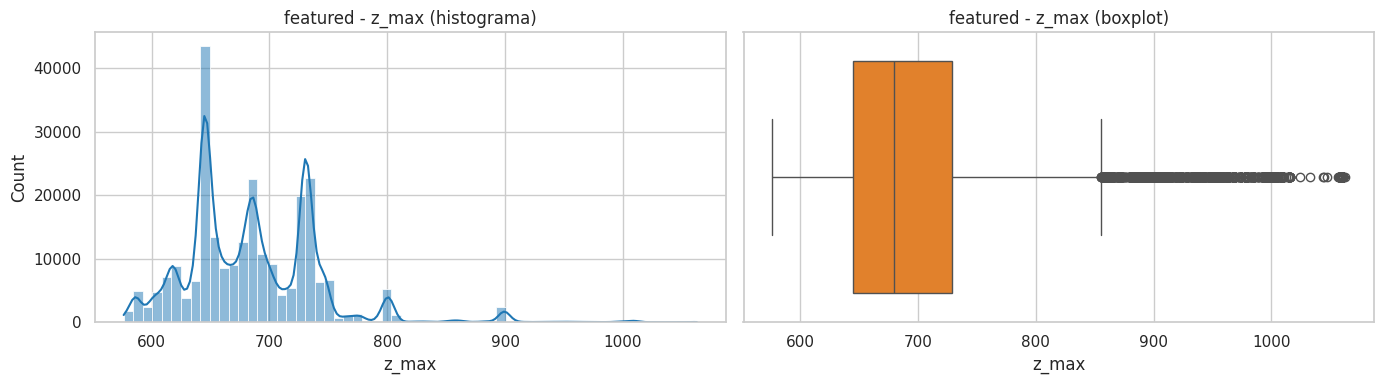

[featured] z_max | col=z_max | invalid_pct=0.09% | outlier_pct=1.72% | valid_rows=1607639
Variable: z_mean (FEATURED)


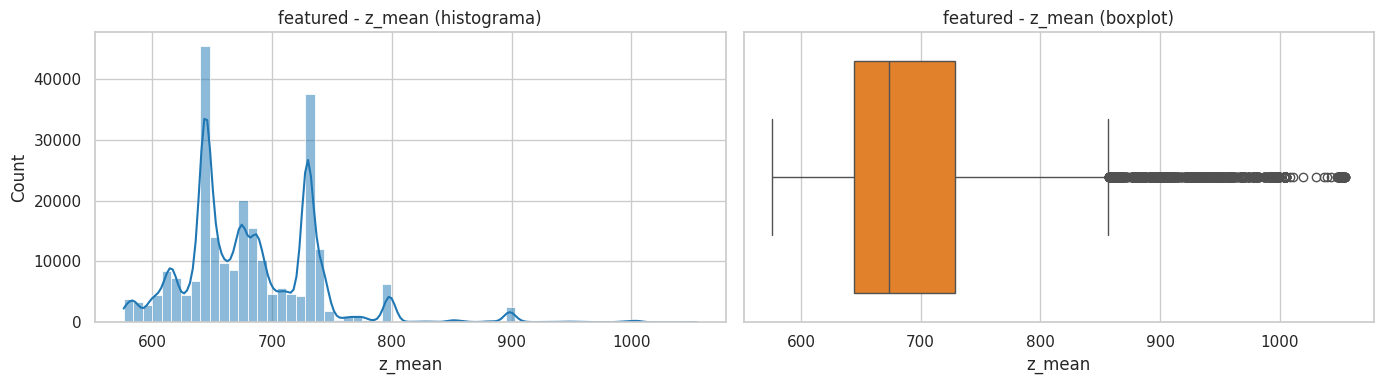

[featured] z_mean | col=z_mean | invalid_pct=0.09% | outlier_pct=1.61% | valid_rows=1607639
Variable: z_std (FEATURED)


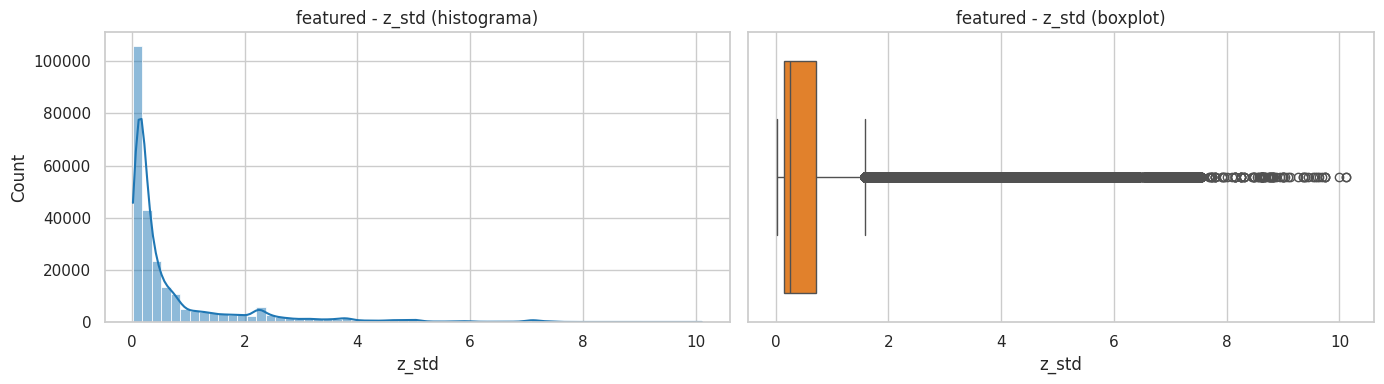

[featured] z_std | col=z_std | invalid_pct=0.09% | outlier_pct=14.68% | valid_rows=1607639
Variable: z_range (FEATURED)


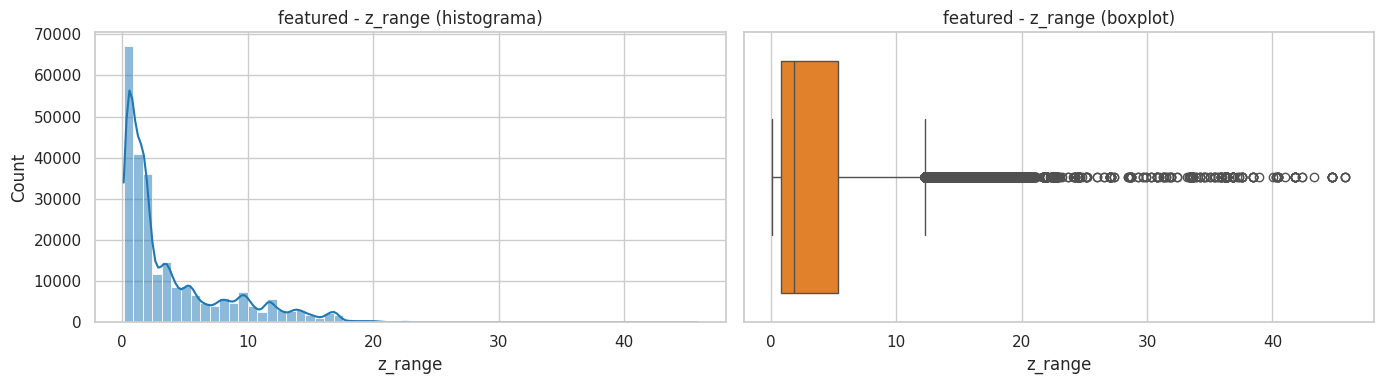

[featured] z_range | col=z_range | invalid_pct=0.09% | outlier_pct=6.75% | valid_rows=1607639
Variable: n_points_used (FEATURED)


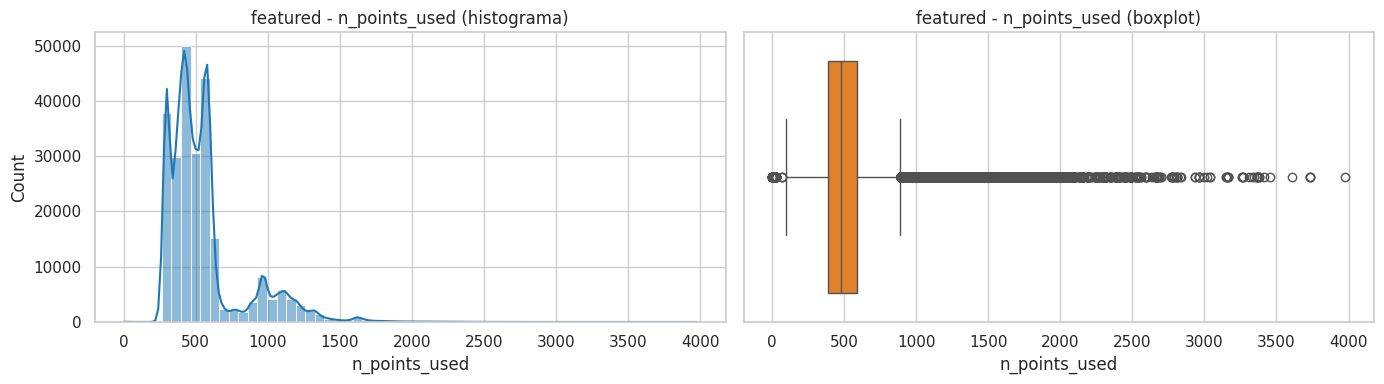

[featured] n_points_used | col=n_points_used | invalid_pct=0.51% | outlier_pct=13.79% | valid_rows=1600915

Resumen FEATURED


,stage,variable,column_used,rows,valid_rows,invalid_pct,outlier_pct_over_valid,mean,std,min,max
0,featured,ax,ax,1609105,1609105,0.000000,11.443194,-50.532267,59.456795,-588.530000,462.140000
1,featured,gx,gx,1609105,1609105,0.000000,16.136672,-39.714274,2272.874606,-120638.350000,109873.140000
2,featured,gz,gz,1609105,1609105,0.000000,27.497273,143.056577,4187.518717,-80366.650000,92192.020000
3,featured,gy,gy,1609105,1609105,0.000000,17.012190,17.433038,2619.311008,-72282.090000,91179.730000
4,featured,ay,ay,1609105,1609105,0.000000,14.819045,22.301299,110.472542,-330.500000,835.460000
5,featured,az,az,1609105,1609105,0.000000,21.319118,1002.896262,29.127044,505.570000,1379.700000
6,featured,roll,roll,1609105,1609105,0.000000,10.866910,25.433301,1054.033863,-1381.510000,51686.360000
7,featured,pitch,pitch,1609105,1609105,0.000000,9.520572,2.340114,11.229562,-246.080000,623.870000
8,featured,yaw,yaw,1609105,1609105,0.000000,13.471837,80.222640,2514.664816,-44673.220000,33410.910000
9,featured,si,si,1609105,1609105,0.000000,5.208734,0.903897,0.075160,0.080000,1.000000


In [9]:
featured_summaries = []
all_feature_vars = {}
all_feature_vars.update(BASE_VARIABLES)
all_feature_vars.update(FEATURE_VARIABLES)

for var_name, aliases in all_feature_vars.items():
    print("=" * 90)
    print(f"Variable: {var_name} (FEATURED)")
    featured_summaries.append(plot_variable_distribution(featured_df, var_name, aliases, "featured"))

featured_summary_df = pd.DataFrame(featured_summaries)
print("\nResumen FEATURED")
display(featured_summary_df)


## Resumen final

Recomendaciones para modelado:

- Revisar variables con alto `% invalid_pct` antes de entrenar.
- Si hay `% outlier_pct_over_valid` muy alto, evaluar clipping/winsorization o escalado robusto.
- Si la distancia de map-matching muestra cola larga, revisar segmentos problematicos antes del entrenamiento final.
- Guardar tablas de resumen por etapa como CSV para trazabilidad entre experimentos.
